# Análisis Exploratorio de Datos Financieros para la Identificación de Estructuras Latentes en las Acciones de Microsoft (2000 - 2026)

## Introducción
El presente Análisis Exploratorio de Datos (EDA) tiene como objetivo estudiar el comportamiento histórico de los precios de las acciones de Microsoft a partir de un conjunto de datos diarios que incluye variables como los precios de apertura, máximo, mínimo y cierre ajustado, así como el volumen de negociación. Este análisis se enmarca dentro del estudio de series de tiempo financieras, donde el interés principal radica en comprender cómo evolucionan los precios de una acción a lo largo del tiempo y qué patrones pueden identificarse en dicha evolución.

Se busca examinar el comportamiento histórico del precio de la acción de Microsoft (MSFT), identificar patrones temporales, evaluar su estructura estadística y analizar la dinámica de la volatilidad a lo largo del período 2000–2026. A través de este análisis exploratorio se busca describir estadísticamente las variables del conjunto de datos y visualizar su evolución temporal, con un enfoque en el histórico temporal (Cierre y Fecha). Esto permitirá obtener una comprensión inicial del comportamiento de la acción y servirá como base para análisis posteriores más avanzados, como la modelación de series de tiempo para la predicción de los valores del retorno.

El propósito principal de este estudio es analizar la dinámica temporal del precio de la acción para caracterizar su comportamiento mediante métricas fundamentales en finanzas cuantitativas, especialmente el retorno y la volatilidad.Este estudio será realizado en distintas ventanas temporales para analizar de forma más precisa la variación de estos valores a lo largo del tiempo, además de identificar tendencias y patrones en los distintos periodos.

Este enfoque permitirá obtener una visión clara y estructurada del comportamiento histórico de la acción, proporcionando una base sólida para interpretar la evolución de su precio en distintos periodos de tiempo.

## Contextualización
Microsoft fue fundada el 4 de abril de 1975 por Bill Gates y Paul Allen, consolidándose como líder en el desarrollo de software. Un hito fundamental fue su salida a bolsa el 13 de marzo de 1986, con un precio inicial de 21 USD por acción. Este análisis trabaja con una serie temporal de frecuencia diaria, abarcando desde el año 2000 hasta el 2026, lo que suma un total de 6,578 observaciones. La serie se caracteriza por una tendencia alcista de largo plazo, con episodios de alta volatilidad durante crisis financieras como la burbuja puntocom (2000-2002) y la crisis financiera global (2008-2009). Además, se observa un crecimiento exponencial reciente impulsado por servicios en la nube e inteligencia artificial.

## Planteamiento del Problema
El precio de las acciones de Microsoft (MSFT) constituye una serie de tiempo financiera con comportamientos complejos: tendencias de largo plazo, fluctuaciones abruptas y períodos de volatilidad diferenciada. Comprender esta dinámica histórica es esencial antes de aplicar cualquier modelo predictivo, ya que un análisis exploratorio riguroso permite identificar patrones, detectar anomalías y caracterizar estadísticamente el activo.


Sin este paso previo, la aplicación de modelos de series de tiempo como ARIMA o GARCH carecería de fundamento empírico, aumentando el riesgo de modelar incorrectamente el comportamiento del precio.


### Pregunta de investigación:

¿Qué patrones de retorno y volatilidad caracterizan el comportamiento histórico de la acción de Microsoft durante el período 2000–2026, y qué estructura presenta la serie como base para su modelación?


## Objetivos

### Objetivo general
Evaluar la estructura estadística y la dinámica temporal de MSFT mediante un EDA robusto fundamentado en econometría financiera, con el fin de aplicar modelos predictivos para los valores de retorno y de volatibilidad.

### Objetivos Específicos

- **Validar Estacionariedad:** Aplicar la prueba ADF para identificar la presencia de raíces unitarias en la serie de precios de MSFT.

- **Identificar Tendencia:** Implementar medias móviles en ventana diaria, trimestral y anual $(n=1, n= 60, n=252)$ como herramienta de suavizamiento para mitigar el ruido en la serie temporal.

- **Analizar Riesgo:** Determinar el grado de Leptocurtosis en la distribución de los retornos logarítmicos como medida del riesgo de cola.

- **Estabilizar la Serie:** Transformar los precios en retornos logarítmicos para obtener una serie con varianza estable y propiedades estadísticas interpretables.

## Marco Teórico

### Retorno
El **retorno** es una medida ampliamente utilizada en finanzas para analizar la variación relativa de un activo en el tiempo. Se define como:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

donde \( P_t \) es el precio en el tiempo \( t \). Su principal ventaja es que permite trabajar con series más cercanas a la **estacionariedad**, facilita la agregación en el tiempo y simplifica el análisis estadístico.



### Volatilidad
La **volatilidad** mide la magnitud de las fluctuaciones de una serie financiera, es decir, el grado de variabilidad de los retornos. Es un indicador clave del **riesgo** de un activo. En series de tiempo financieras, es común observar fenómenos como el *clustering de volatilidad*, donde periodos de alta volatilidad tienden a agruparse, lo que motiva el uso de modelos como ARCH y GARCH.

$$
\sigma = \sqrt{\frac{1}{n-1} \sum_{t=1}^{n} (r_t - \bar{r})^2}
$$

### Estabilización de la Serie: Retornos Logarítmicos
Dado que los precios de los activos suelen exhibir tendencias estocásticas y variabilidad no constante, se procede a transformar los precios en **retornos logarítmicos**. Esta transformación busca obtener una serie con varianza más estable y propiedades estadísticas interpretables (**Hudson y Litzenberg, 2015**). El retorno logarítmico se define como:

$$r_t = \ln(P_t) - \ln(P_{t-1})$$

A diferencia del retorno simple, los log-retornos facilitan la agregación temporal y suelen presentar una distribución más cercana a la normalidad, aunque conservan características críticas para el análisis de riesgo.

### Modelos de Descomposición

#### Modelo Aditivo
El modelo aditivo asume que una serie de tiempo puede expresarse como la suma de sus componentes:

$$
Y_t = T_t + S_t + E_t
$$

donde:
- $T_t$: tendencia  
- $S_t$: estacionalidad  
- $E_t$: componente aleatorio  

Este modelo es adecuado cuando la variación de la serie es aproximadamente constante en el tiempo.


#### Modelo Multiplicativo
El modelo multiplicativo representa la serie como el producto de sus componentes:

$$
Y_t = T_t \times S_t \times E_t
$$

Se utiliza cuando la variabilidad de la serie aumenta o disminuye proporcionalmente con su nivel, como ocurre comúnmente en series financieras.


### Prueba de Dickey-Fuller Aumentada (ADF)
La prueba **ADF (Augmented Dickey-Fuller)** se utiliza para determinar si una serie de tiempo es **estacionaria** o presenta una raíz unitaria. La hipótesis nula establece que la serie no es estacionaria. Un **p-valor bajo** permite rechazar esta hipótesis, indicando que la serie es adecuada para modelado estadístico.

dentificación de Tendencia y Suavizamiento
Para mitigar el ruido inherente a las fluctuaciones diarias de alta frecuencia y extraer la señal de tendencia subyacente, se implementan **medias móviles** como herramienta de suavizamiento (**Sureshkumar et al., 2013**). En este estudio se utilizan ventanas temporales específicas:
* **Diaria ($n=1$):** Representa la serie original sin filtrar.
* **Trimestral ($n=60$):** Suaviza las fluctuaciones de corto plazo.
* **Anual ($n=252$):** Filtra la volatilidad estacional para revelar la tendencia de largo plazo.

**Identificación de Tendencia y Suavizamiento**
Para mitigar el ruido inherente a las fluctuaciones diarias de alta frecuencia y extraer la señal de tendencia subyacente, se implementan **medias móviles** como herramienta de suavizamiento (**Sureshkumar et al., 2013**). En este estudio se utilizan ventanas temporales específicas:
* **Diaria ($n=1$):** Representa la serie original sin filtrar.
* **Trimestral ($n=60$):** Suaviza las fluctuaciones de corto plazo.
* **Anual ($n=252$):** Filtra la volatilidad estacional para revelar la tendencia de largo plazo.


### Función de Autocorrelación (ACF)
La **ACF (Autocorrelation Function)** mide la correlación entre una serie y sus valores pasados (rezagos). Es útil para identificar patrones de dependencia temporal y componentes de tipo **media móvil (MA)** en la serie.



### Función de Autocorrelación Parcial (PACF)
La **PACF (Partial Autocorrelation Function)** mide la correlación entre la serie y un rezago específico, eliminando el efecto de los rezagos intermedios. Es fundamental para identificar el orden de los componentes **autorregresivos (AR)** en modelos de series de tiempo.

## Descripción de los datos

El dataset utilizado contiene el seguimiento historico del precio en dólares (USD) de las acciones de Microsoft en Nasdaq, desde el 3 de Enero del año 2000, hasta la fecha de 27 de Febrero de 2026. Cabe resaltar que los precios mostrados por el dataset están ajustados según la inflación, para facilitar la interpretación.

- **Fuente:** Nasdaq
- **Frecuencia:** Diaria
- **Variables Clave:** Fecha (Date) y Precio de cierre diario (Close)



In [ ]:
# Instalar Yahoo Finance
!pip install yfinance

# Importar librerías
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings("ignore")

# Análisis Preliminar
Se descargan los datos históricos de Microsoft desde el año 2000 yfinance genera un MultiIndex en las columnas (variable + ticker), por lo que se elimina el segundo nivel para simplificar el acceso.

Incialmente se debe realizar una inspección general sobre el dataset seleccionado:

In [ ]:
import os
import shutil

original_path = "/content/Análisis de Series de Tiempo Financieras — Microsoft (MSFT).ipynb"
temp_path = "/content/analysis.ipynb"

# Check if the original notebook exists
if not os.path.exists(original_path):
    print(f"Error: The notebook '{original_path}' was not found.")
    print("Please ensure the notebook is in the /content/ directory and the filename is exactly correct (including special characters like '—').")
else:
    # Copy the notebook to a simpler name to avoid potential parsing issues
    shutil.copy(original_path, temp_path)

    # Run nbconvert on the simplified name
    # --log-level=40 will show only error messages, keeping output minimal upon success
    !jupyter nbconvert --to html --log-level=40 "{temp_path}"

    # Clean up the temporary file
    os.remove(temp_path)

    print(f"Notebook successfully converted to HTML at {temp_path.replace('.ipynb', '.html')}")

# Display files in the current directory to help locate the notebook
print("\n--- Files in /content/ directory ---")
for f in os.listdir('/content/'):
    print(f)

Error: The notebook '/content/Análisis de Series de Tiempo Financieras — Microsoft (MSFT).ipynb' was not found.
Please ensure the notebook is in the /content/ directory and the filename is exactly correct (including special characters like '—').

--- Files in /content/ directory ---
.config
sample_data


In [ ]:
!jupyter nbconvert --to html "/content/Análisis de Series de Tiempo Financieras — Microsoft (MSFT).ipynb"

[NbConvertApp] WARNING | pattern '/content/Análisis de Series de Tiempo Financieras — Microsoft (MSFT).ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Eq

In [ ]:
sns.set_style("darkgrid")

In [ ]:
import yfinance as yf
ticker = 'MSFT'
dfmicrosoft = yf.download(ticker, start="2000-01-01")
dfmicrosoft.columns = dfmicrosoft.columns.droplevel(1)  #Elimina nivel del ticker
print('Column names: ', dfmicrosoft.columns)
dfmicrosoft = dfmicrosoft[dfmicrosoft.index <= '2026-02-27']
dfmicrosoft.head()

/tmp/ipykernel_750/1285024925.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dfmicrosoft = yf.download(ticker, start="2000-01-01")
[*********************100%***********************]  1 of 1 completed

Column names:  Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,35.520378,36.148889,34.130036,35.767973,53228400
2000-01-04,34.320488,35.691784,34.206213,34.606175,54119000
2000-01-05,34.682369,35.463246,33.330119,33.863401,64059600
2000-01-06,33.520584,34.701423,33.025394,34.187187,54976600
2000-01-07,33.958630,34.206225,32.701608,33.101569,62013600


Para obtener una idea del tamaño de los datos en número de filas y columnas ejecutamos la siguiente línea

In [ ]:
print('No. of rows, columns:', dfmicrosoft.shape)

No. of rows, columns: (6578, 5)


El conjunto de datos descargado contiene 6.578 observaciones (filas) y 5 variables (columnas). Las 6.578 filas representan registros diarios del comportamiento de la acción de Microsoft desde el 1 de enero del año 2000 hasta la fecha de descarga de los datos, que es el 27 de Febrero de 2026. Es decir, cada fila corresponde a un día de negociación en el mercado bursátil. Las 5 columnas corresponden a las variables financieras fundamentales: precio de apertura (Open), precio máximo (High), precio mínimo (Low), precio de cierre (Close) y volumen de transacciones (Volume). En conjunto, el tamaño del dataset indica que se dispone de una serie temporal extensa, con más de dos décadas de información diaria, lo que resulta adecuado para realizar un análisis exploratorio robusto y estudiar la evolución histórica y la volatilidad de la acción en el largo plazo.

In [ ]:
dfmicrosoft.isna().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


Por lo anterior, podemos confirmar que no hay valores faltantes.

In [ ]:
dfmicrosoft.dtypes

,0
Price,
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


El análisis de los tipos de datos (dtypes) muestra que las variables de precios (Open, High, Low y Close) están almacenadas como float64, lo que indica que son variables numéricas continuas con decimales. Esto es consistente con la naturaleza de los precios financieros, que pueden tomar valores con alta precisión decimal.

Por otro lado, la variable Volume está registrada como int64, lo que significa que representa valores enteros. Esto es coherente con su definición, ya que el volumen corresponde al número total de acciones negociadas en cada jornada y, por tanto, no puede tomar valores fraccionarios.

En términos generales, la estructura de los tipos de datos es adecuada para realizar cálculos financieros, tales como rendimientos, desviaciones estándar y otras medidas estadísticas necesarias para el análisis de volatilidad.
La variable fecha no aparece dentro de data.dtypes porque no es una columna, sino el índice del DataFrame. Por lo tanto, para conocer su tipo de dato se debe consultar el tipo del índice.

Se puede verificar con:

In [ ]:
type(dfmicrosoft.index)

pandas.core.indexes.datetimes.DatetimeIndex

La fecha está almacenada como un DatetimeIndex (datetime64[ns]), lo que confirma que el conjunto de datos está estructurado como una serie temporal. Esto es fundamental para el análisis de volatilidad, ya que permite realizar operaciones basadas en el tiempo, como cálculos de rendimientos diarios, agregaciones mensuales o análisis por periodos específicos.

In [ ]:
# Extraer variables clave para el análisis de volatilidad
close_series = dfmicrosoft[['Close']].copy()           # Precio de cierre
close_series.columns = ['Close']       # Renombra la columna para facilitar su acceso
close_series

,Close
Date,
2000-01-03,35.520378
2000-01-04,34.320488
2000-01-05,34.682369
2000-01-06,33.520584
2000-01-07,33.958630
...,...
2026-02-23,384.470001
2026-02-24,389.000000
2026-02-25,400.600006


En particular, para el análisis de volatilidad y rendimientos será fundamental trabajar con la columna Close, ya que el precio de cierre es la variable estándar utilizada en estudios financieros para calcular variaciones porcentuales y medir riesgo.

Antes de proceder con los gráficos y cálculos correspondientes, es conveniente verificar que la columna Close esté presente en el conjunto de datos. Esto se puede comprobar inspeccionando los nombres de las columnas del DataFrame.

Realizar esta validación previa garantiza que los análisis posteriores como el cálculo de rendimientos diarios o la estimación de la volatilidad se ejecuten correctamente y sobre la variable adecuada.

# Estadísticas descriptivas

In [ ]:
close_series.describe()

,Close
count,6578.000000
mean,101.007925
std,132.559090
min,11.113185
25%,18.987722
50%,25.980840
75%,129.123367
max,539.825256


Las estadísticas descriptivas del precio de cierre (Close) se calculan sobre 6.578 observaciones diarias, lo que confirma la amplitud temporal del conjunto de datos. El precio promedio de cierre durante el período analizado es de 101,01 USD, mientras que la desviación estándar es de 132,56 USD, un valor elevado en relación con la media. Esto indica una alta dispersión de los precios y, por tanto, una variabilidad considerable a lo largo del tiempo. El valor mínimo registrado fue de 11,11 USD, mientras que el máximo alcanzó 539,83 USD, lo que evidencia un crecimiento significativo de la acción en el largo plazo.

En cuanto a la distribución:

- El 25% de los precios se sitúa por debajo de 18,99 USD.

- La mediana (50%) es 25,98 USD.

- El 75% de las observaciones está por debajo de 129,12 USD.

La diferencia marcada entre la mediana y la media sugiere la presencia de asimetría positiva (sesgo a la derecha), causada por los valores altos registrados en los años más recientes. En conjunto, estos resultados reflejan una tendencia creciente de largo plazo acompañada de una alta variabilidad, elementos fundamentales en el análisis de la volatilidad histórica de la acción.

In [ ]:
close_series.head()

,Close
Date,
2000-01-03,35.520378
2000-01-04,34.320488
2000-01-05,34.682369
2000-01-06,33.520584
2000-01-07,33.958630


In [ ]:
close_series.tail()

,Close
Date,
2026-02-23,384.470001
2026-02-24,389.000000
2026-02-25,400.600006
2026-02-26,401.720001
2026-02-27,392.739990


Se observa que el precio de cierre el 03/01/2000 fue de 35,52 USD, seguido de una disminución el 04/01/2000 a 34,32 USD. Posteriormente, el precio presenta ligeras fluctuaciones en los días siguientes, con movimientos tanto positivos como negativos. Este comportamiento inicial evidencia que el precio de la acción experimenta variaciones diarias constantes, lo cual es característico de los mercados financieros. Además, confirma que la serie está correctamente indexada por fecha, lo que permite analizar la evolución temporal del activo y calcular posteriormente los retornos diarios para el estudio de la volatilidad.

# Visualización de la serie

### Visualización temporal

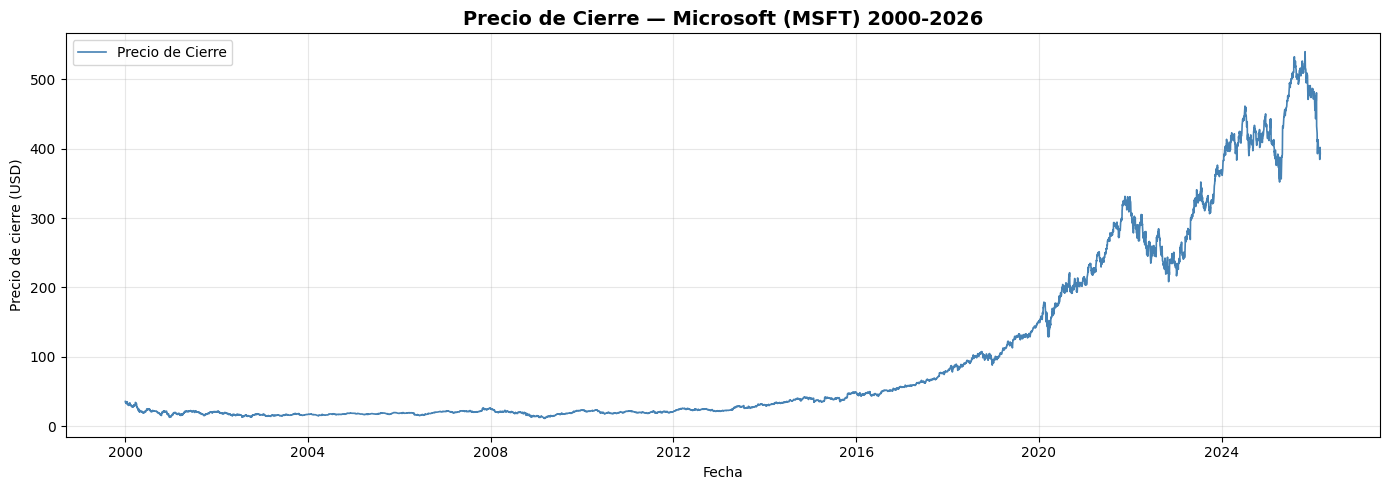

In [ ]:
import matplotlib.pyplot as plt

# Filtrar filas donde Close no sea nulo
df_plot = close_series.loc[~pd.isnull(close_series['Close']), :]

# Fechas dinámicas
year_inicio = df_plot.index.min().year
year_fin = df_plot.index.max().year

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot.index, df_plot['Close'], color='steelblue', linewidth=1.2, label='Precio de Cierre')

ax.set_title(f'Precio de Cierre — Microsoft (MSFT) {year_inicio}-{year_fin}', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio de cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra la evolución histórica del precio de cierre de la acción de Microsoft desde el año 2000 hasta 2026. Se observa claramente una tendencia creciente de largo plazo, especialmente marcada a partir de 2013–2014, donde el precio inicia una fase de expansión sostenida. Durante los primeros años (2000–2010), el precio se mantiene relativamente estable, con fluctuaciones moderadas y sin una tendencia pronunciada. Posteriormente, se identifica un cambio estructural en la dinámica del activo, caracterizado por un crecimiento acelerado que lleva el precio desde niveles cercanos a 30–40 USD hasta superar los 500 USD en años recientes.

También se observan episodios de caídas significativas y correcciones temporales, como en periodos de alta incertidumbre del mercado, lo que evidencia que, aunque la tendencia general es alcista, el activo experimenta fases de alta volatilidad. Desde el punto de vista estadístico, la serie en niveles no parece estacionaria, ya que presenta una tendencia clara y cambios en la varianza a lo largo del tiempo. Esto justifica la necesidad de trabajar con retornos en lugar de precios para el análisis de volatilidad.

### Visualización de los retornos

Una vez comprobado todo esto, hay que pasar a la construcción del retorno y la volatibilidad dentro del dataset, el **retorno** mide a variación porcentual del precio de un activo entre dos períodos consecutivos, para este análisis, se utilizará la fórmula del retorno logarítmico, usualmente empleada en campos financieros:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Donde $P_t$ es el precio de cierre (Close) en el día $t$. Por consiguiente, empleando esta fórmula, se añadirá una nueva columna al dataset que contenga esta variable para cada día, exceptuando el primero:

In [ ]:
#Calcular returns si no existen
close_series['Returns'] = close_series['Close'].pct_change()

close_series.head()

/tmp/ipykernel_750/1063379009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_series['Returns'] = close_series['Close'].pct_change()


,Close,Returns
Date,,
2000-01-03,35.520378,NaN
2000-01-04,34.320488,-0.033780
2000-01-05,34.682369,0.010544
2000-01-06,33.520584,-0.033498
2000-01-07,33.958630,0.013068


El retorno diario ya se encuentra calculado para el dataset, excepto para la primera fecha, ya que no hay un día anterior a este. Luego está el cáclulo de la volatibilidad histórica, esta se define como la desviación estándar de los retornos y constituye una medida estadística del riesgo del activo, que mide el grado de variabilidad o dispersión de los retornos de un activo en el tiempo, una mayor volatilidad implica mayor incertidumbre y variabilidad en los rendimientos. Para este caso, se trabajará la volatibilidad historica sobre distintas ventanas móviles en lugar de un solo periodo de tiempo, para eso se utilizará el $Rolling$ $Standard$ $Deviation$, que es la volatibilidad (Desviación estandar), calculada sobre una ventana móvil de tamaño fijo:

$$
\sigma = \sqrt{\frac{1}{n-1} \sum_{t=1}^{n} (r_t - \bar{r})^2}
$$

Donde:

- $r_t$ es el retorno en el periodo $t$.
- $\bar{r}$ es el retorno medio.
- $n$ es el número de observaciones por ventana.

Es importante mencionar, que estas variables deben ser analizadas en distintas ventanas de tiempo, para obtener una comprensión más clara sobre el comportamiento de estas variables en distintos periodos. Una vez establecido esto, se puede proceder al análisis de las variables.

Ahora pasemos con el análisis estadistico del retorno diario:

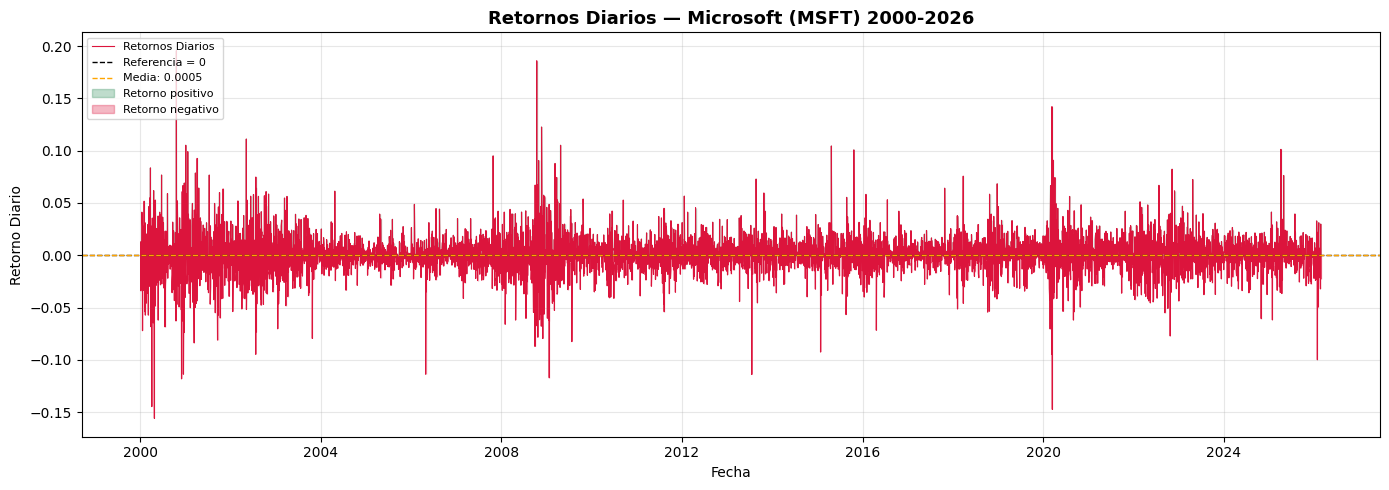

In [ ]:
import numpy as np
#Convertir a arrays numpy
close_np = np.array(close_series['Close'].dropna())
returns_np = np.array(close_series['Returns'].dropna())
# Gráfico de retornos en el tiempo
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Returns'],
        color='crimson', linewidth=0.8, label='Retornos Diarios')

ax.axhline(0, color='black', linestyle='--', linewidth=1.0, label='Referencia = 0')
ax.axhline(close_series['Returns'].mean(), color='orange', linestyle='--',
           linewidth=1.0, label=f"Media: {close_series['Returns'].mean():.4f}")

ax.fill_between(close_series.index, close_series['Returns'], 0,
                where=close_series['Returns'] >= 0, color='seagreen', alpha=0.3, label='Retorno positivo')
ax.fill_between(close_series.index, close_series['Returns'], 0,
                where=close_series['Returns'] < 0, color='crimson', alpha=0.3, label='Retorno negativo')

ax.set_title(f'Retornos Diarios — Microsoft (MSFT) {year_inicio}-{year_fin}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno Diario')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra el comportamiento de los retornos diarios de la acción de Microsoft a lo largo del período 2000–2026. Se observa que los retornos fluctúan alrededor de cero, lo que indica que no existe una tendencia determinística en las variaciones porcentuales, a diferencia del precio en niveles. Un aspecto fundamental que se evidencia en la gráfica es el clustering de volatilidad: los movimientos de gran magnitud tienden a agruparse en ciertos períodos específicos. Es decir, fases de alta volatilidad (con retornos extremos positivos y negativos) son seguidas por otros días igualmente volátiles, mientras que existen intervalos prolongados donde los retornos son relativamente pequeños y estables.

También se identifican episodios de retornos extremos tanto positivos como negativos, algunos superiores al ±10%, lo que refleja la presencia de shocks de mercado o eventos de alta incertidumbre. Estos eventos contribuyen significativamente a la dispersión total de la serie y son característicos de los activos financieros. Desde el punto de vista estadístico, la serie de retornos parece oscilar alrededor de una media cercana a cero y presenta variabilidad cambiante en el tiempo (heterocedasticidad), lo cual justifica el análisis detallado de la volatilidad y posibles modelos dinámicos para su estimación.


### Distribución de los retornos

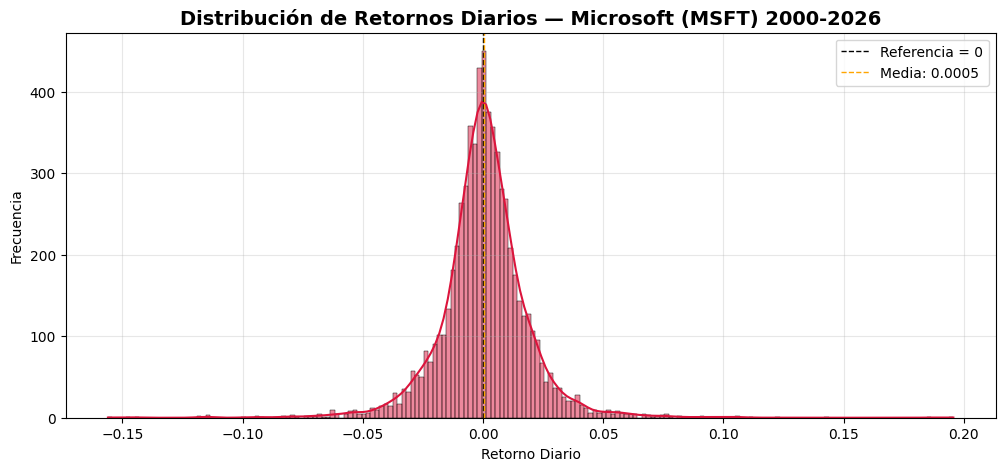

In [ ]:
import seaborn as sns
# Calcular returns si no existen
close_series['Returns'] = close_series['Close'].pct_change()

# Convertir a arrays numpy
close_np = np.array(close_series['Close'].dropna())
returns_np = np.array(close_series['Returns'].dropna())

# ── Distribución de los Retornos ───────────────────────────────
plt.figure(figsize=(12, 5))
g = sns.histplot(returns_np, kde=True, color='crimson')
g.set_title(f'Distribución de Retornos Diarios — Microsoft (MSFT) {year_inicio}-{year_fin}',
            fontsize=14, fontweight='bold')
plt.xlabel('Retorno Diario')
plt.ylabel('Frecuencia')
# Línea de referencia en cero
plt.axvline(0, color='black', linestyle='--', linewidth=1.0, label='Referencia = 0')
plt.axvline(close_series['Returns'].mean(), color='orange', linestyle='--',
            linewidth=1.0, label=f"Media: {close_series['Returns'].mean():.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La distribución de los retornos diarios muestra que la mayoría de las variaciones porcentuales se concentran alrededor de cero, lo cual es consistente con el comportamiento típico de los activos financieros: en la mayoría de los días los movimientos son relativamente pequeños. La media aproximada de 0.0005 (0.05%) indica que, en promedio, la acción presenta un rendimiento diario ligeramente positivo en el largo plazo. Sin embargo, la media es muy cercana a cero en comparación con la dispersión, lo que sugiere que el comportamiento diario está dominado por la volatilidad más que por la tendencia.
La forma de la distribución es aproximadamente simétrica alrededor de cero, pero presenta colas pronunciadas (colas gruesas). Esto implica que la probabilidad de observar movimientos extremos es mayor que la que predeciría una distribución normal. En otras palabras, existen retornos muy grandes —tanto positivos como negativos— que ocurren con mayor frecuencia de lo que asumiría un modelo gaussiano. Además, el pico central es relativamente alto, lo que indica una fuerte concentración de observaciones cerca de la media, mientras que las colas extendidas reflejan eventos de alta incertidumbre o shocks de mercado.

Desde el punto de vista financiero, este comportamiento es característico de las series de retornos y sugiere:

- Presencia de leptocurtosis (colas pesadas).

- Alta concentración de valores cercanos a cero.

- Existencia de eventos extremos que incrementan el riesgo.

- No normalidad de la distribución.

En consecuencia, la gráfica confirma que la volatilidad no es constante y que los retornos presentan episodios extremos que deben ser considerados en cualquier análisis de riesgo o modelación estadística.

## Análisis de componentes

Es momento de dividir la serie en componentes para analizar tendencia, estacionalidad residuales, este proceso se hará sobre el precio de cierre utiilizando la tecnica STL (Seasonal-Trend), se hará con una frecuencia de 252 días, ya que se trabajará anualmente:

### Descomposición clásica y ADF

Junto a la descomposición, también se realizará la prueba ADF. La prueba ADF (Augmented Dickey-Fuller) es un método estadístico utilizado en el análisis de series de tiempo para determinar si una serie, como los retornos financieros, es estacionaria o presenta una raíz unitaria. En un EDA, se aplica sobre los retornos para verificar si sus propiedades estadísticas (media y varianza) se mantienen constantes en el tiempo, lo cual es un supuesto clave para muchos modelos. Generalmente, los retornos tienden a ser estacionarios, y un resultado significativo en la prueba ADF (p-valor bajo) indica que se puede rechazar la hipótesis nula de no estacionariedad, validando así su uso en modelado financiero.

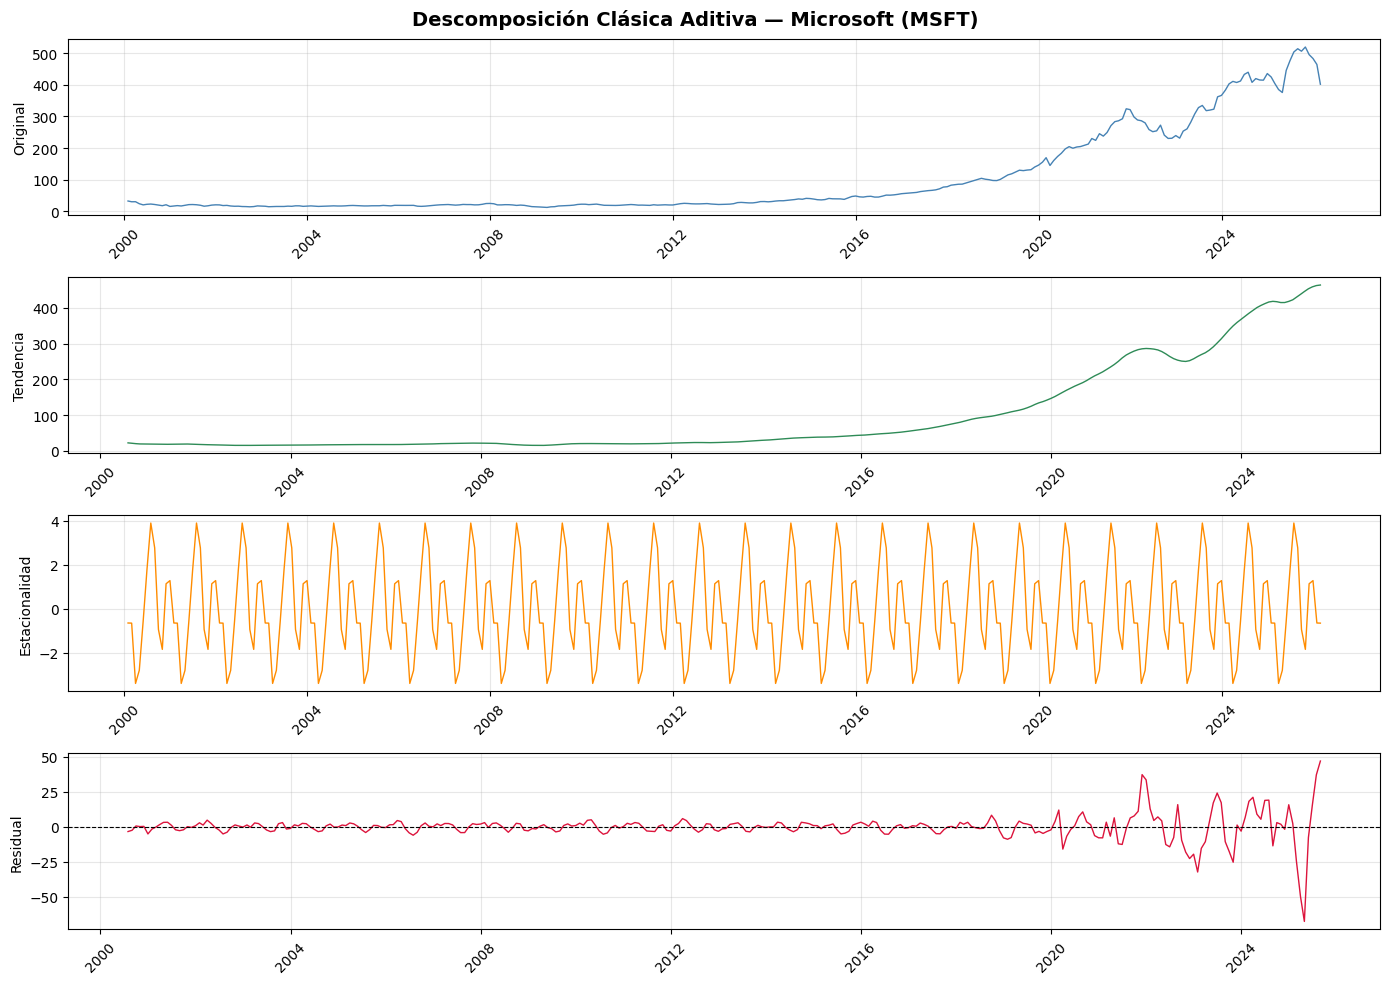

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Usamos Close para la descomposición
# Resampleamos a frecuencia mensual para que la estacionalidad sea más clara
serie = close_series['Close'].resample('ME').mean().dropna()

# ── Descomposición Clásica Aditiva ─────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición Clásica Aditiva — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

decomp_add = seasonal_decompose(serie, model='additive', period=12)

axes[0].plot(decomp_add.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp_add.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp_add.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp_add.resid, color='crimson', linewidth=1.0)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

#Aplicar prueba ADF para Close
adf_result1 = adfuller(close_series['Close'])

print("Estadístico ADF para Close:", adf_result1[0])
print("p-valor:", adf_result1[1])

print('')

returns = close_series['Returns'].dropna()
#Aplicar prueba ADF para retornos
adf_result2 = adfuller(returns)

print("Estadístico ADF para Retornos:", adf_result2[0])
print("p-valor:", adf_result2[1])

Estadístico ADF para Close: 0.7140416165747457
p-valor: 0.9901139683208092



KeyError: 'Returns'

In [ ]:
#Calcular returns si no existen
close_series['Returns'] = close_series['Close'].pct_change()

close_series.head()

,Close,Returns
Date,,
2000-01-03,35.520378,NaN
2000-01-04,34.320488,-0.033780
2000-01-05,34.682369,0.010544
2000-01-06,33.520584,-0.033498
2000-01-07,33.958630,0.013068


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

#Aplicar prueba ADF para Close
adf_result1 = adfuller(close_series['Close'])

print("Estadístico ADF para Close:", adf_result1[0])
print("p-valor:", adf_result1[1])

print('')

returns = close_series['Returns'].dropna()
#Aplicar prueba ADF para retornos
adf_result2 = adfuller(returns)

print("Estadístico ADF para Retornos:", adf_result2[0])
print("p-valor:", adf_result2[1])

Estadístico ADF para Close: 0.7140416165747457
p-valor: 0.9901139683208092

Estadístico ADF para Retornos: -28.06445441407153
p-valor: 0.0


Con el objetivo de analizar la estructura interna de la serie temporal del precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema aditivo (Dujmovic, 2025). Este procedimiento separa la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— bajo el supuesto de fluctuaciones estacionales de magnitud constante, representada como $Y_t = T_t + S_t + R_t$ (Jensen et al., 2018). La serie evidencia no estacionariedad con tendencia creciente acelerada desde 2013-2015 y volatilidad creciente post-2019, confirmando heterocedasticidad en residuales típica de series financieras (Dujmovic, 2025; Jensen et al., 2018). Esta prueba contrasta la hipótesis nula $𝐻_0$ de presencia de raíz unitaria (serie no estacionaria) frente a la hipótesis alternativa de estacionariedad.

Para la serie de Precio de Cierre (Close), el estadístico ADF fue 0.7140 con un p-valor de 0.9901. Dado que el p-valor es ampliamente superior al nivel de significancia del 5%, no se rechaza la hipótesis nula. Además, el estadístico ADF es mayor (menos negativo) que todos los valores críticos reportados (1%, 5% y 10%), lo que confirma que la serie presenta raíz unitaria. En consecuencia, el precio de cierre no es estacionario en nivel. Este resultado es consistente con el análisis gráfico previo, donde se observó una tendencia creciente de largo plazo y cambios en la media a lo largo del tiempo.

En contraste, para la serie de Retornos Diarios (Returns), el estadístico ADF fue -28.0644 con un p-valor prácticamente igual a 0.0000. En este caso, el p-valor es menor que 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria. Adicionalmente, el estadístico es mucho más negativo que los valores críticos, lo que proporciona evidencia contundente de estacionariedad. Esto indica que la serie de retornos no presenta tendencia determinística ni raíz unitaria, y que sus fluctuaciones se mantienen alrededor de una media constante.

En conjunto, los resultados confirman un comportamiento típico de series financieras: los precios en niveles no son estacionarios, mientras que sus retornos sí lo son. Este hallazgo justifica el uso de los retornos para el modelamiento econométrico y el análisis de volatilidad, ya que la mayoría de los modelos de series de tiempo requieren estacionariedad para producir inferencias válidas.

Ahora se procede a realizar la descomposición con enfoque multiplicativo.

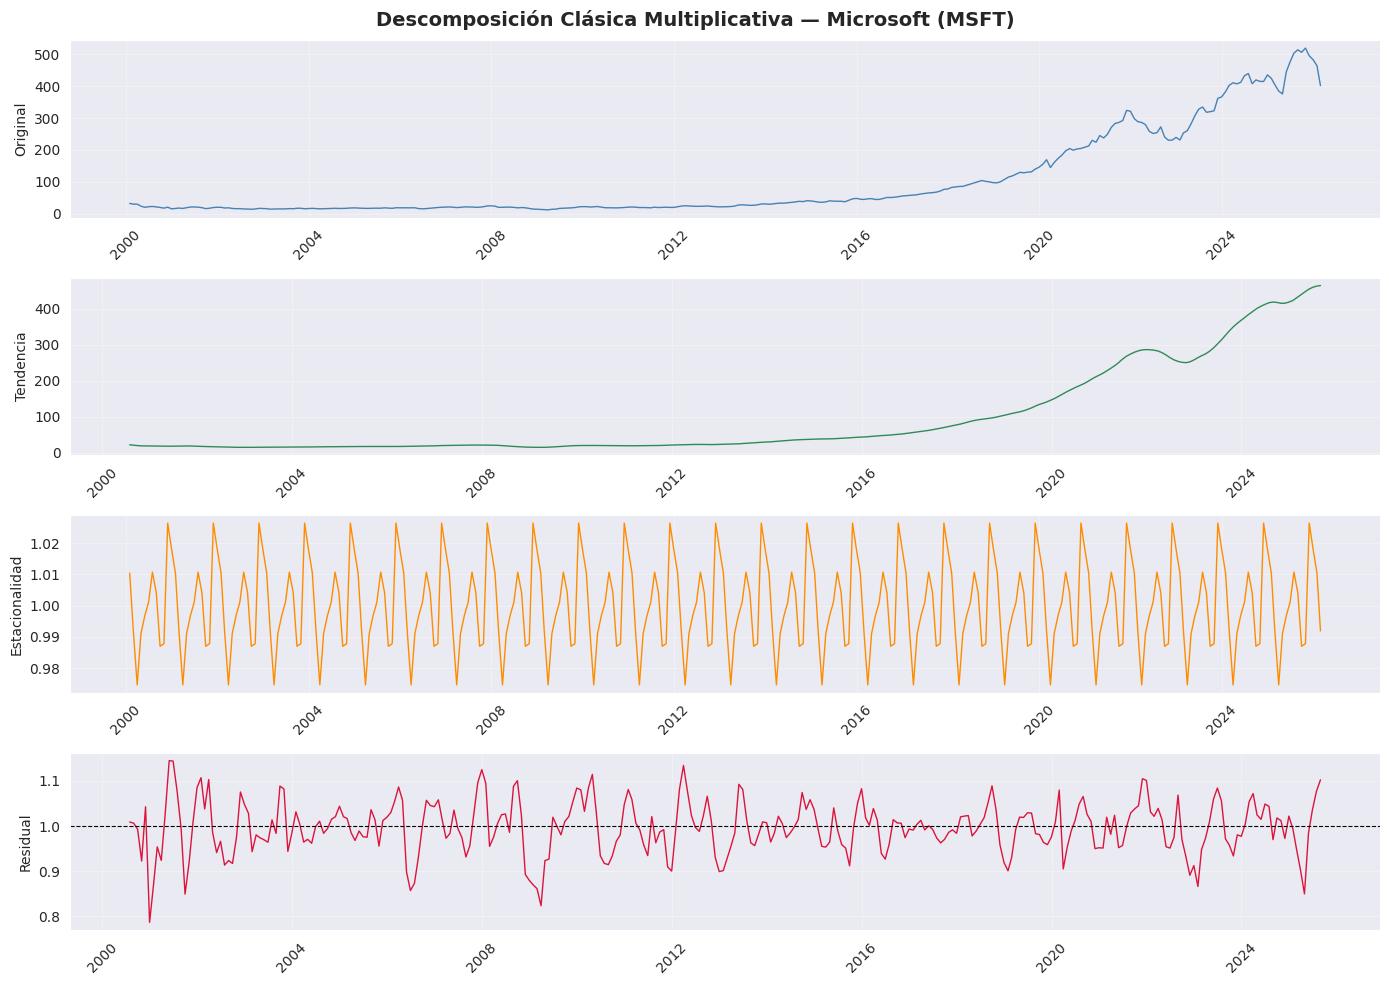

In [ ]:
# ── Descomposición Clásica Multiplicativa ──────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición Clásica Multiplicativa — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

decomp_mul = seasonal_decompose(serie, model='multiplicative', period=12)

axes[0].plot(decomp_mul.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp_mul.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp_mul.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp_mul.resid, color='crimson', linewidth=1.0)
axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Con el propósito de analizar la estructura interna de la serie temporal correspondiente al precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema multiplicativo (Dujmovic, 2025). Este método permite separar la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— asumiendo que las fluctuaciones estacionales e irregulares son proporcionales al nivel de la serie. En este contexto, la serie se modela como $Y_t = T_t \times S_t \times R_t$, donde $Y_t$ corresponde al valor observado en el tiempo $t$, $T_t$ a la tendencia de largo plazo, $S_t$ a la componente estacional y $R_t$ al componente residual o irregular (Jensen et al., 2018).

La serie original evidencia un comportamiento claramente no estacionario, dominado por una tendencia creciente sostenida en el largo plazo. Durante los primeros años del período analizado el crecimiento es relativamente moderado; sin embargo, a partir de aproximadamente 2015 se observa una aceleración significativa en la trayectoria ascendente del precio. Desde 2019–2020 se identifican fluctuaciones de mayor magnitud, lo que refleja un incremento en la volatilidad del activo. Asimismo, las variaciones absolutas se amplifican conforme aumenta el nivel del precio, lo que respalda la elección del modelo multiplicativo, dado que tanto la media como la varianza cambian proporcionalmente con el nivel de la serie (Dujmovic, 2025).
​

El componente de tendencia extraída muestra un crecimiento estructural sostenido, con una pendiente más pronunciada en la segunda mitad del período analizado. Aunque se observan ligeras correcciones en algunos intervalos recientes, la dirección general continúa siendo claramente alcista, lo que indica que el comportamiento de largo plazo del activo ha sido de apreciación estructural consistente (Jensen et al., 2018). Por su parte, el componente estacional oscila alrededor del valor 1, como es característico en los modelos multiplicativos, y presenta una magnitud reducida en comparación con la tendencia. El patrón estacional se mantiene relativamente estable a lo largo del tiempo y no muestra cambios estructurales significativos. La baja amplitud de este componente sugiere que la estacionalidad no constituye un factor determinante en la dinámica del precio diario, por lo que la evolución de la serie está explicada principalmente por la tendencia de largo plazo y las fluctuaciones irregulares (Dujmovic, 2025).
​

Finalmente, el componente residual recoge la variabilidad no explicada por la tendencia ni por la estacionalidad. En los primeros años del período analizado las fluctuaciones residuales son relativamente moderadas; no obstante, a partir de 2018–2020 se observa un incremento en la dispersión, evidenciado por desviaciones más pronunciadas respecto al nivel central de 1. La presencia de picos extremos tanto positivos como negativos es consistente con el comportamiento típico de las series financieras. Este aumento en la amplitud de las variaciones residuales sugiere la existencia de heterocedasticidad, es decir, una varianza no constante en el tiempo, coherente con episodios de mayor volatilidad en periodos recientes (Jensen et al., 2018).
​

En conjunto, el análisis multiplicativo indica que la dinámica del precio está dominada por una tendencia estructural creciente, acompañada de una estacionalidad débil y de un componente irregular cuya variabilidad se intensifica en los periodos recientes. La evidencia de no estacionariedad y de cambios en la varianza refuerza la necesidad de transformar la serie por ejemplo, mediante el cálculo de retornos antes de realizar un análisis formal de la volatilidad o aplicar modelos econométricos de series temporales (Dujmovic, 2025).

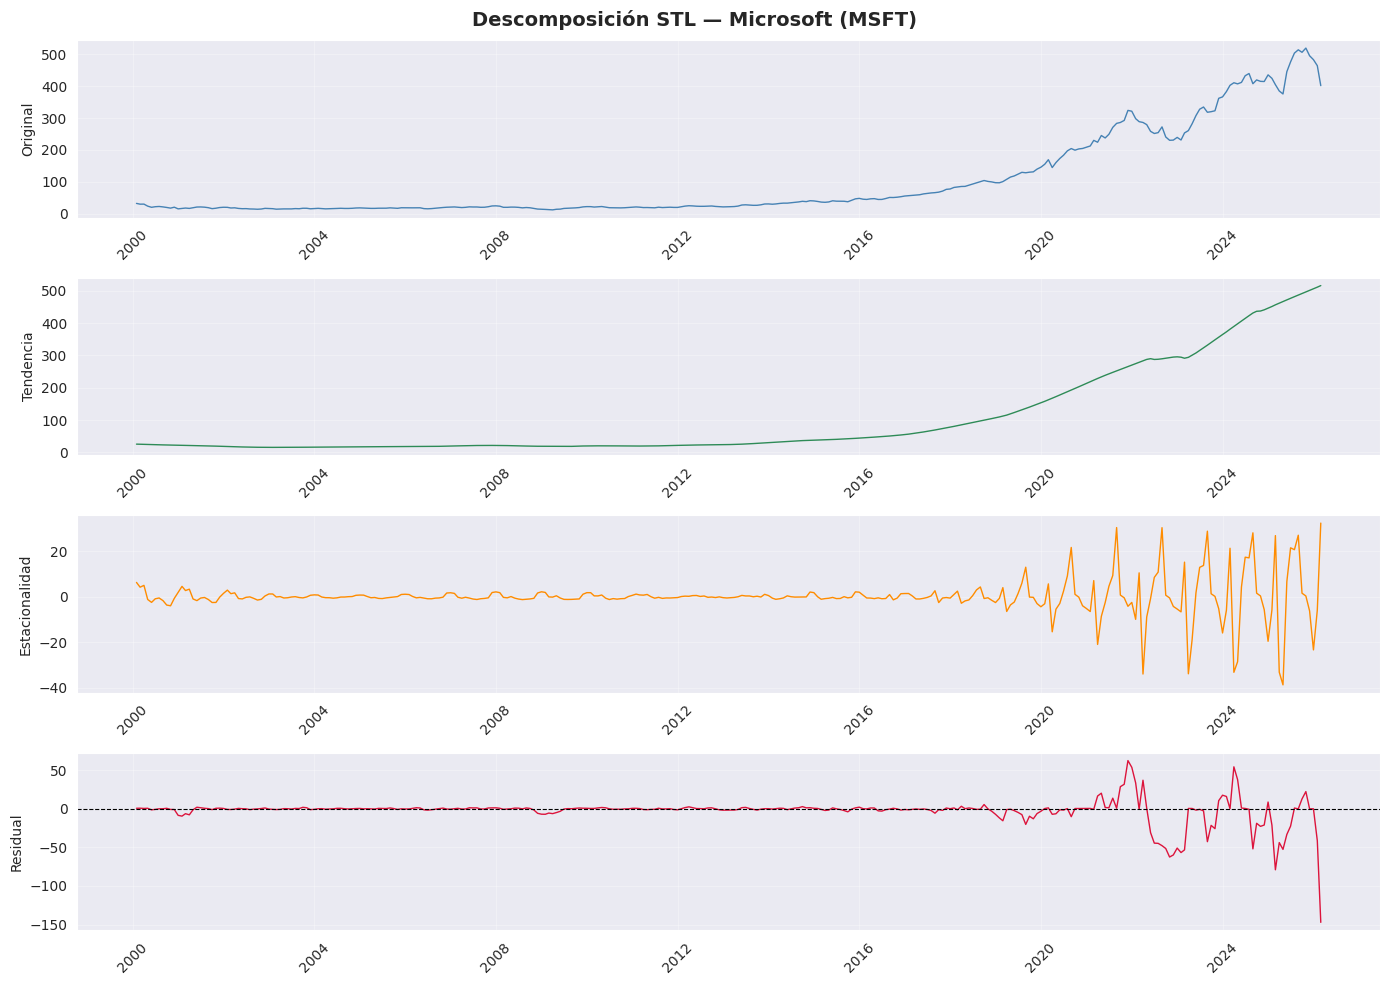

In [ ]:
# ── Descomposición STL ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición STL — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

stl = STL(serie, period=12, robust=True)
stl_fit = stl.fit()

axes[0].plot(stl_fit.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(stl_fit.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(stl_fit.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(stl_fit.resid, color='crimson', linewidth=1.0)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

La descomposición STL de la serie del precio de cierre diario de Microsoft (MSFT) muestra que la dinámica del comportamiento está dominada principalmente por una fuerte tendencia creciente a largo plazo, mientras que la estacionalidad tiene un efecto relativamente pequeño en comparación con la magnitud del nivel de la serie (DataCamp, 2025). En el componente original se observa un crecimiento moderado durante los primeros años, seguido de una aceleración marcada a partir de aproximadamente 2016–2017, intensificándose después de 2020, donde el precio alcanza niveles históricamente altos antes de presentar correcciones recientes. Este patrón confirma la presencia de un cambio estructural en la pendiente de crecimiento en la última década.
​

El componente de tendencia estimado mediante suavizamiento LOESS refleja claramente este comportamiento: durante los primeros años la pendiente es casi plana, luego se vuelve positiva y progresivamente más pronunciada, especialmente en el período posterior a 2019 (Cleveland et al., 1990). Esto indica que el crecimiento del precio no ha sido lineal, sino acelerado, lo cual es consistente con procesos de expansión empresarial, mayor capitalización bursátil y shocks macroeconómicos que amplifican movimientos de mercado. Desde el punto de vista econométrico, esto implica que la serie no es estacionaria en media.
​

En cuanto al componente estacional, se observa que durante gran parte del período histórico las fluctuaciones son pequeñas y cercanas a cero, lo que sugiere que no existe una estacionalidad fuerte y persistente en el precio (DataCamp, 2025). Sin embargo, en los años más recientes la amplitud de las oscilaciones estacionales aumenta ligeramente. Aun así, su magnitud sigue siendo reducida frente al nivel total de la serie, por lo que la estacionalidad no parece ser el factor dominante en la dinámica del precio. Esto es coherente con lo esperado en precios accionarios, donde los patrones estacionales suelen ser débiles en comparación con la tendencia y la volatilidad.
​

El componente residual muestra un comportamiento particularmente relevante para el análisis de volatilidad. Durante los primeros años los residuos permanecen relativamente cercanos a cero, con baja dispersión. No obstante, a partir de aproximadamente 2018–2019 se observa un incremento notable en la variabilidad, con picos positivos y negativos mucho más pronunciados, especialmente en el período posterior a 2020 (DataCamp, 2025). Esto evidencia un claro fenómeno de heterocedasticidad: la varianza de los errores no es constante en el tiempo y aumenta en los períodos recientes. Además, se observan shocks extremos en los últimos años, lo que sugiere episodios de alta incertidumbre y mayor riesgo de mercado.
​

En conjunto, la descomposición STL indica que el comportamiento del precio de Microsoft se explica principalmente por una tendencia creciente de largo plazo, con una estacionalidad débil y un componente residual cuya variación aumenta significativamente en el tiempo (Cleveland et al., 1990). Para un análisis de volatilidad, esto respalda la necesidad de trabajar con retornos en lugar de precios y considerar modelos que capturan heterocedasticidad condicional, como modelos ARCH o GARCH, dado que la evidencia visual muestra clustering de volatilidad en los períodos más recientes (DataCamp, 2025).

## Detección de anomalías

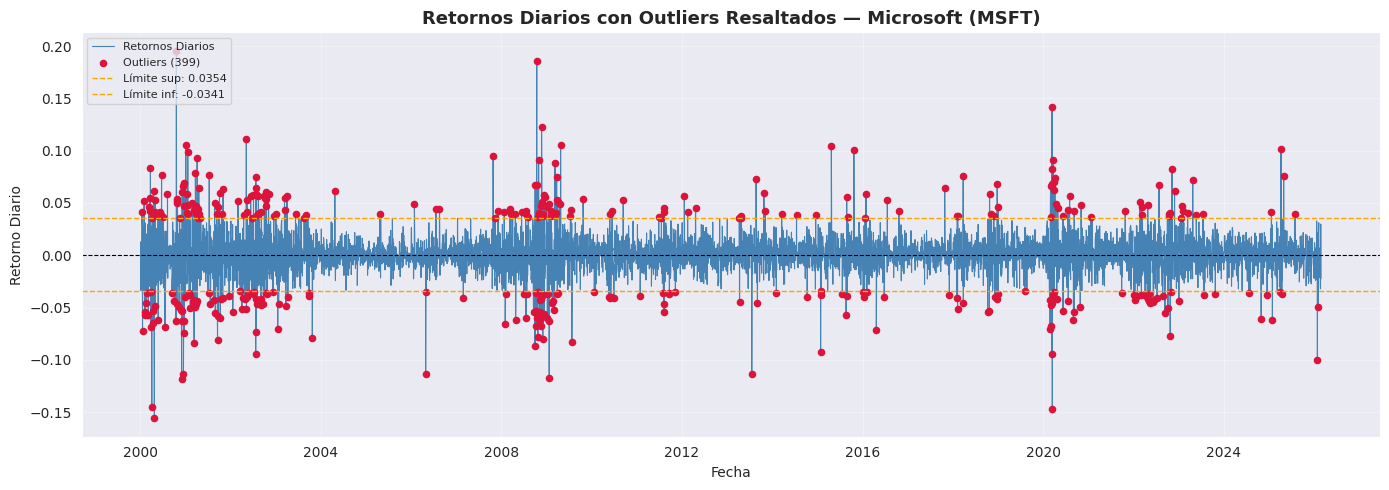

In [ ]:
# ── Detección de Outliers por IQR ─────────────────────────────
Q1 = close_series['Returns'].quantile(0.25)
Q3 = close_series['Returns'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = close_series[
    (close_series['Returns'] < limite_inf) |
    (close_series['Returns'] > limite_sup)
]

# ── Serie temporal con outliers resaltados ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Returns'],
        color='steelblue', linewidth=0.8, label='Retornos Diarios', zorder=1)
ax.scatter(outliers.index, outliers['Returns'],
           color='crimson', s=20, zorder=2, label=f'Outliers ({len(outliers)})')
ax.axhline(limite_sup, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite sup: {limite_sup:.4f}')
ax.axhline(limite_inf, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite inf: {limite_inf:.4f}')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_title('Retornos Diarios con Outliers Resaltados — Microsoft (MSFT)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno Diario')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica de los retornos diarios de Microsoft muestra una serie centrada alrededor de cero, sin tendencia en los medios, pero con una variabilidad que cambia a lo largo del tiempo, evidenciando volatilidad no constante (Engle, 1982). Se observan periodos donde los retornos presentan poca dispersión y otros donde los movimientos son mucho más amplios, lo que confirma la presencia de heterocedasticidad condicional (Bollerslev, 1986).

Los puntos resaltados en rojo representan valores extremos que superan los límites establecidos (aproximadamente ±3.5%). Estos valores atípicos no aparecen de forma uniforme, sino que se concentran en ciertos períodos, reflejando claramente el fenómeno de clustering de volatilidad, donde grandes movimientos tienden a agruparse en el tiempo (Engle, 2001).

Además, la presencia de numerosos valores extremos sugiere que la distribución de los retornos presenta colas pesadas y se aleja del supuesto de normalidad. En conjunto, la gráfica confirma la existencia de heterocedasticidad condicional y respalda la necesidad de utilizar modelos que capturen la dinámica de la volatilidad, como los modelos ARCH o GARCH (Bollerslev, 1986).

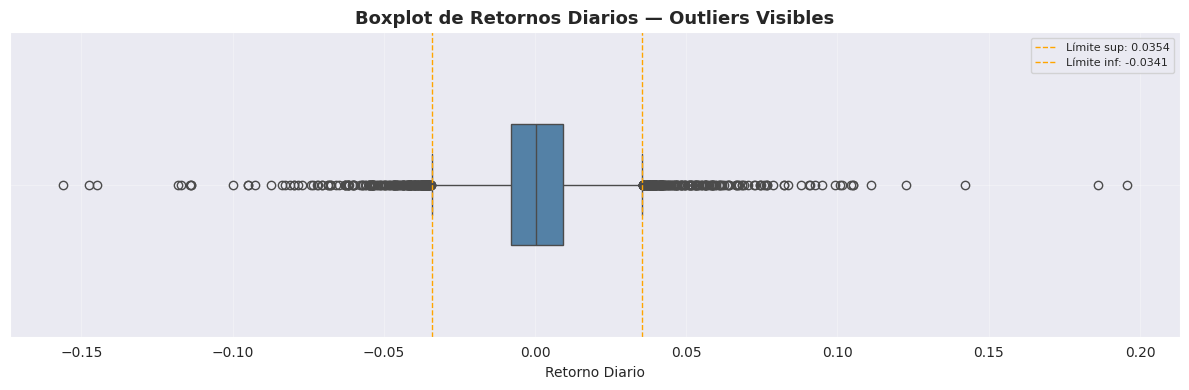

In [ ]:
# ── Boxplot con outliers ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(data=close_series['Returns'].dropna(), orient='h',
            color='steelblue', width=0.4, ax=ax)

ax.set_title('Boxplot de Retornos Diarios — Outliers Visibles',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno Diario')
ax.axvline(limite_sup, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite sup: {limite_sup:.4f}')
ax.axvline(limite_inf, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite inf: {limite_inf:.4f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El boxplot de los retornos diarios muestra que la mediana se encuentra muy cercana a cero, lo que confirma que en promedio los retornos no presentan sesgo significativo en los medios. La mayor parte de las observaciones se concentra en un rango relativamente estrecho (dentro del rango intercuartílico), lo que indica que los movimientos “normales” del precio suelen ser moderados.

Sin embargo, se observan numerosos valores atípicos a ambos lados de la distribución, superando los límites aproximados de ±3.5%. Estos puntos extremos reflejan la presencia de colas pesadas, característica típica de series financieras, y evidencian que ocurren extremos con mayor frecuencia de lo que se esperaría bajo una distribución normal.

Además, se aprecia cierta asimetría en la magnitud de algunos valores extremos, especialmente en la cola negativa, lo que sugiere que las caídas abruptas pueden ser más pronunciadas que las subidas en determinados periodos. En conjunto, el boxplot confirma alta curtosis, presencia de valores atípicos y comportamiento no normal en la distribución de los retornos.

In [ ]:
# ── Top 10 outliers más extremos ──────────────────────────────
print(f"\n{'═'}")
print(f"  10 OUTLIERS MÁS EXTREMOS")
print(f"{'═'*50}")
top_outliers = outliers['Returns'].abs().nlargest(10)
display(close_series.loc[top_outliers.index, ['Close', 'Returns']].round(4))


═
  10 OUTLIERS MÁS EXTREMOS
══════════════════════════════════════════════════


,Close,Returns
Date,,
2000-10-19,18.8553,0.1957
2008-10-13,18.4530,0.1860
2000-04-24,20.3028,-0.1560
2020-03-16,128.6363,-0.1474
2000-04-03,27.6926,-0.1447
2020-03-13,150.8737,0.1422
2008-11-21,14.3378,0.1226
2000-11-30,17.4840,-0.1182
2009-01-22,12.4655,-0.1171


# Estacionalidad y periodicidad

### ACF & PACF con respecto al Precio de Cierre

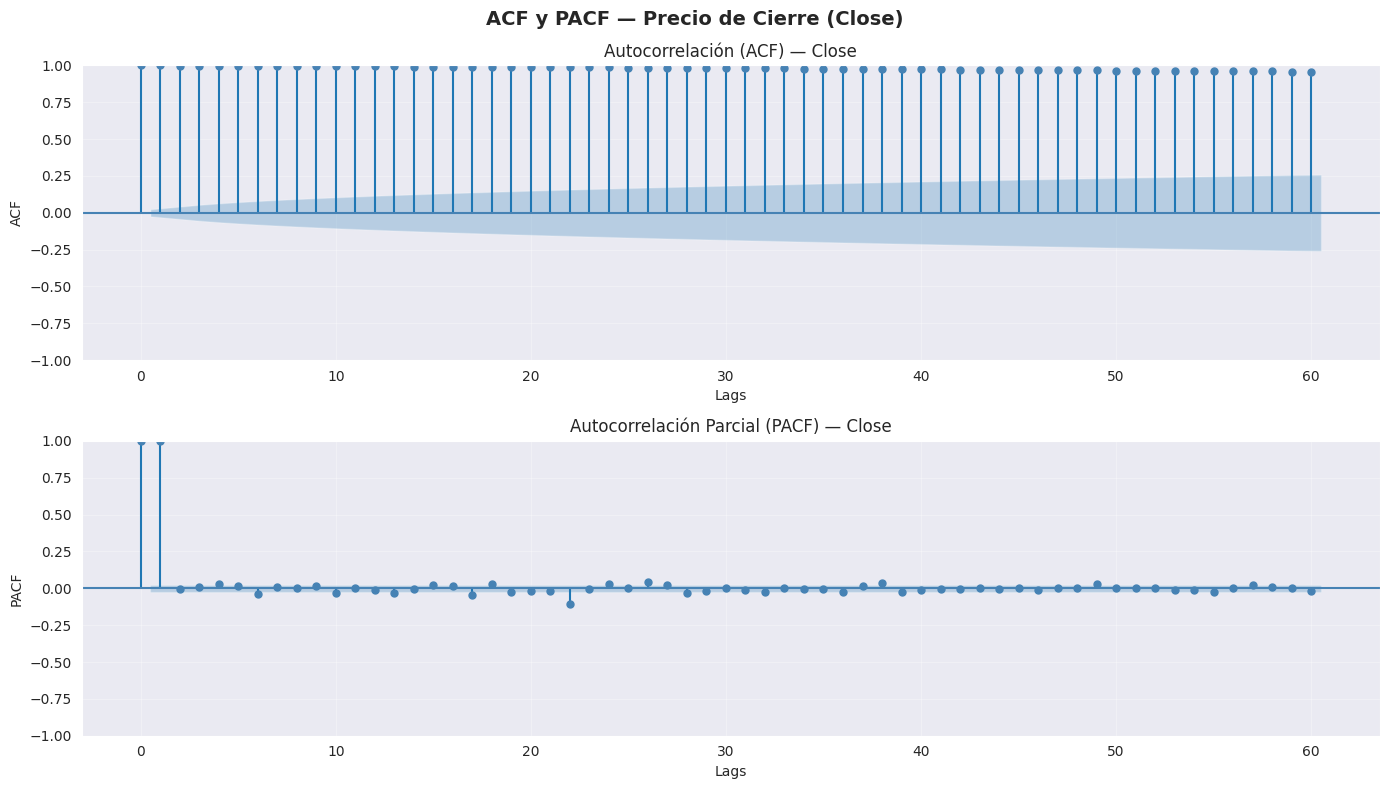

 Interpretación — Close:
   • ACF decae lentamente → la serie NO es estacionaria,
     existe una tendencia fuerte a largo plazo.
   • PACF significativo en lag 1 → sugiere un proceso
     AR(1), base para modelado ARIMA.


In [ ]:
# ── ACF DEL Precio de Cierre ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Precio de Cierre (Close)',
             fontsize=14, fontweight='bold')

plot_acf(close_series['Close'].dropna(), lags=60, ax=axes[0],
         color='steelblue', title='')
axes[0].set_title('Autocorrelación (ACF) — Close')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(close_series['Close'].dropna(), lags=60, ax=axes[1],
          color='steelblue', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Close')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Close:")
print("   • ACF decae lentamente → la serie NO es estacionaria,")
print("     existe una tendencia fuerte a largo plazo.")
print("   • PACF significativo en lag 1 → sugiere un proceso")
print("     AR(1), base para modelado ARIMA.")

La ACF muestra valores muy altos y positivos en casi todos los rezagos (lags), decayendo muy lentamente. Esto indica fuerte persistencia y una clara tendencia en la serie del precio de cierre. En otras palabras, el precio actual está altamente correlacionado con muchos períodos pasados → la serie no es estacionaria (Morales, 2013).

La PACF presenta un pico muy significativo en el rezago 1 y luego los demás valores son pequeños y cercanos a cero. Esto sugiere que la dependencia principal es de corto plazo (lag 1), pero la alta persistencia observada en la ACF confirma que el problema principal es la tendencia (CEPAL, s.f.).


El precio en niveles no es estacionario presenta raíz unitaria (comportamiento tipo random walk con tendencia)

Requiere diferenciación (trabajar con retornos o primera diferencia) antes de modelar con ARIMA

En resumen: el precio en niveles no es adecuado para modelado directo; es mejor trabajar con retornos o con la serie diferenciada (Morales, 2013).

### ACF y PACF de Retornos

La ACF (función de autocorrelación) y la PACF (función de autocorrelación parcial) son herramientas fundamentales en el análisis de series de tiempo. La ACF mide la correlación entre una serie y sus propios rezagos, permitiendo identificar patrones de dependencia temporal y posibles componentes de tipo MA (media móvil). Por su parte, la PACF mide la correlación directa entre la serie y un rezago específico, eliminando el efecto de los rezagos intermedios, lo que resulta útil para identificar componentes AR (autorregresivos).

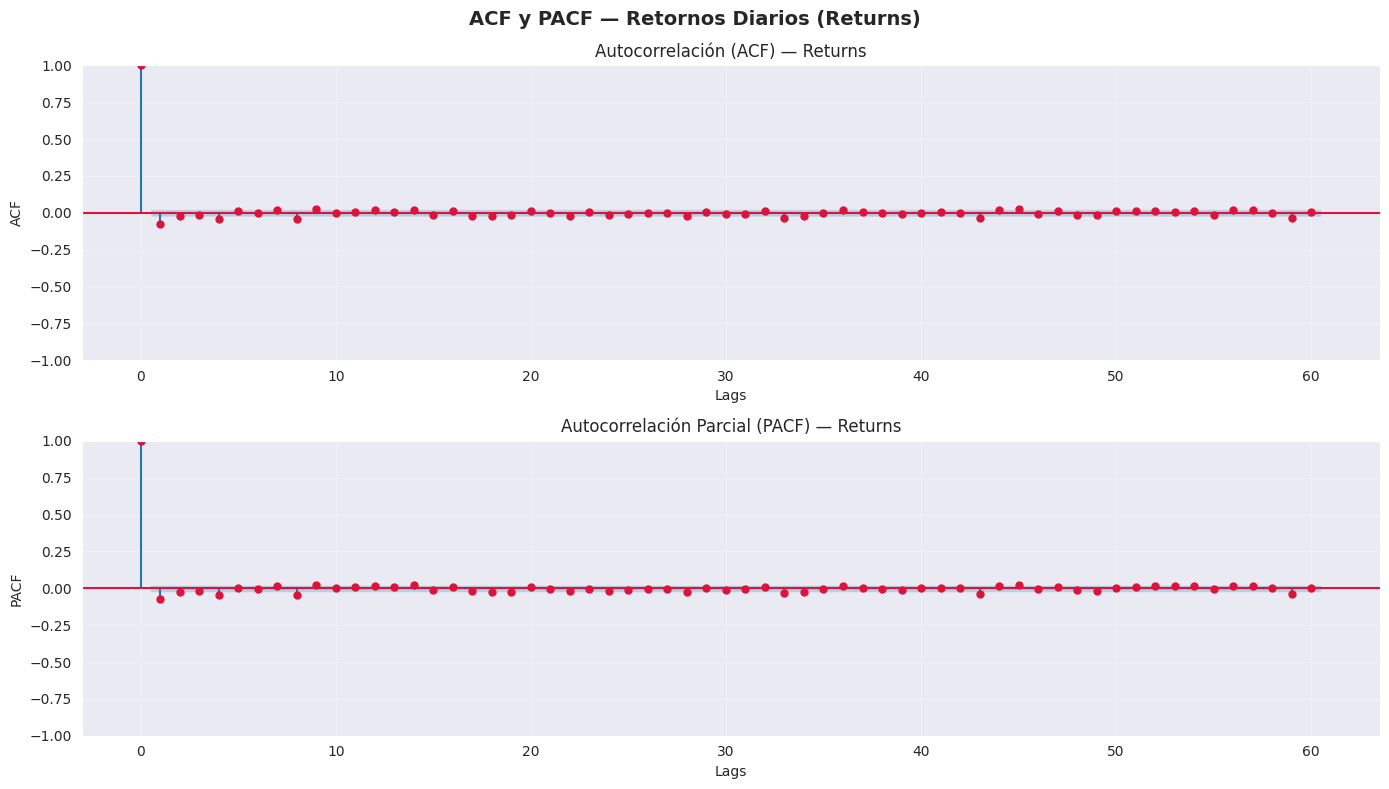

 Interpretación — Returns:
   • ACF cae rápidamente a cero → los retornos son
     aproximadamente estacionarios (comportamiento esperado).
   • Pocas autocorrelaciones significativas → mercado
     eficiente, los retornos pasados no predicen bien los futuros.


In [ ]:
# ──  ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Retornos Diarios (Returns)',
             fontsize=14, fontweight='bold')

plot_acf(close_series['Returns'].dropna(), lags=60, ax=axes[0],
         color='crimson', title='')
axes[0].set_title('Autocorrelación (ACF) — Returns')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(close_series['Returns'].dropna(), lags=60, ax=axes[1],
          color='crimson', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Returns')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Returns:")
print("   • ACF cae rápidamente a cero → los retornos son")
print("     aproximadamente estacionarios (comportamiento esperado).")
print("   • Pocas autocorrelaciones significativas → mercado")
print("     eficiente, los retornos pasados no predicen bien los futuros.")

ACF (Autocorrelación)
La ACF muestra valores muy altos y positivos en casi todos los rezagos (lags), decayendo muy lentamente. Esto indica fuerte persistencia y una clara tendencia en la serie del precio de cierre. En otras palabras, el precio actual está altamente correlacionado con muchos períodos pasados → la serie no es estacionaria (Morales, 2013).
​

PACF (Autocorrelación Parcial)
La PACF presenta un pico muy significativo en el rezago 1 y luego los demás valores son pequeños y cercanos a cero. Esto sugiere que la dependencia principal es de corto plazo (lag 1), pero la alta persistencia observada en la ACF confirma que el problema principal es la tendencia (CEPAL, s.f.)

En resumen: el precio en niveles no es adecuado para modelado directo; es mejor trabajar con retornos o con la serie diferenciada (Morales, 2013).


### ACF de Retornos Cuadrados (Volatilidad)

El ACF (función de autocorrelación) aplicado a los retornos cuadrados permite analizar la dependencia temporal en la volatilidad de una serie financiera. Aunque los retornos suelen comportarse como ruido blanco (sin autocorrelación), sus cuadrados capturan la magnitud de las variaciones y suelen evidenciar patrones de persistencia conocidos como clustering de volatilidad. Este análisis es importante ya que permite identificar si existen periodos de alta y baja volatilidad agrupados en el tiempo, lo cual es clave para justificar el uso de modelos como ARCH o GARCH en la modelación financiera.

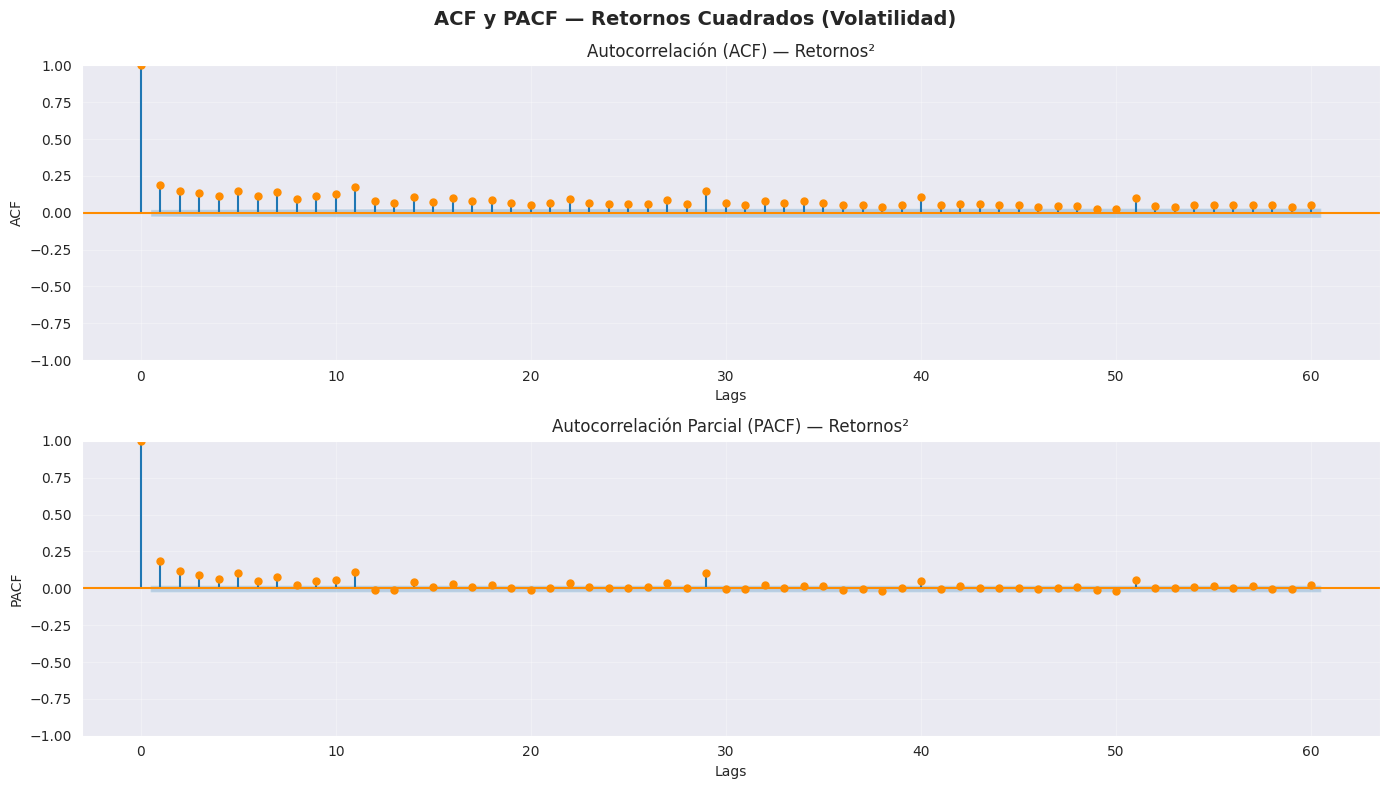

 Interpretación — Retornos Cuadrados:
   • ACF significativa y persistente → existe agrupamiento
     de volatilidad (volatility clustering).
   • Esto confirma que períodos de alta volatilidad tienden
     a ser seguidos por más alta volatilidad → justifica
     el uso de modelos GARCH para modelar la varianza.


In [ ]:
# ──  ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Retornos Cuadrados (Volatilidad)',
             fontsize=14, fontweight='bold')

returns_sq = close_series['Returns'].dropna() ** 2

plot_acf(returns_sq, lags=60, ax=axes[0],
         color='darkorange', title='')
axes[0].set_title('Autocorrelación (ACF) — Retornos²')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(returns_sq, lags=60, ax=axes[1],
          color='darkorange', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Retornos²')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Retornos Cuadrados:")
print("   • ACF significativa y persistente → existe agrupamiento")
print("     de volatilidad (volatility clustering).")
print("   • Esto confirma que períodos de alta volatilidad tienden")
print("     a ser seguidos por más alta volatilidad → justifica")
print("     el uso de modelos GARCH para modelar la varianza.")

En el ACF de los retornos cuadrados , se observan autocorrelaciones positivas y significativas en varios rezagos, que decaen lentamente. Esto indica que la volatilidad no es ruido blanco, sino que presenta persistencia temporal . Es decir, cuando hay alta volatilidad en un período, es probable que continúe en los siguientes. Este comportamiento es típico del fenómeno de agrupación de volatilidad en series financieras.

En la PACF de los retornos cuadrados , se aprecia un pico fuerte en el primer rezago y luego valores pequeños que van disminuyendo. Esto sugiere que gran parte de la dependencia de la volatilidad se explica en los primeros rezagos, aunque sigue habiendo cierta memoria.

En conjunto, estas gráficas indican heterocedasticidad condicional y presencia de efectos ARCH/GARCH . En términos prácticos, la volatilidad de los retornos de Microsoft es dependiente del pasado y sería adecuada modelarla con un modelo tipo GARCH en lugar de asumir varianza constante.

### Diagramas de caja por periodo

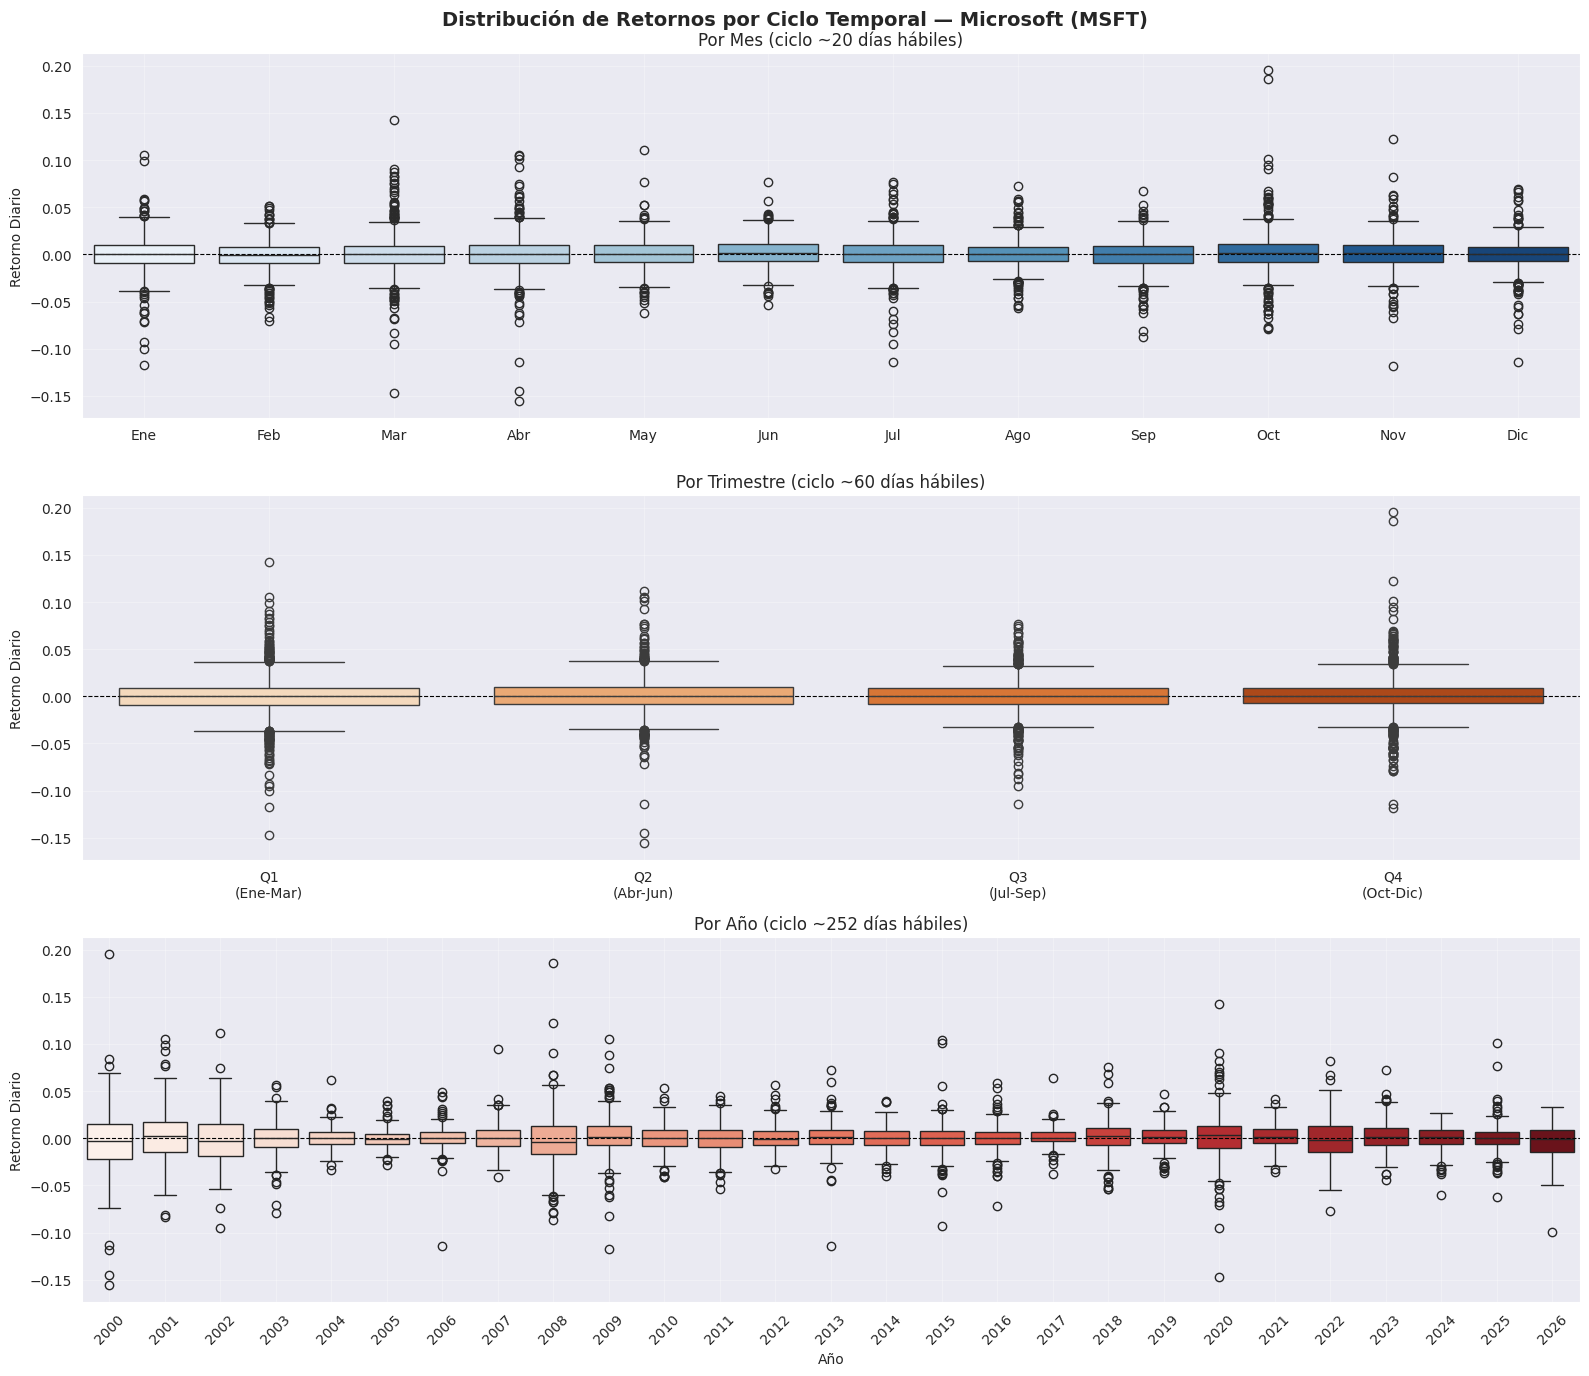

In [ ]:
# ── Crear columnas de ciclos temporales ───────────────────────
close_series['Mes'] = close_series.index.month
close_series['Trimestre'] = close_series.index.quarter
close_series['Año'] = close_series.index.year

# ── Gráfica combinada ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Distribución de Retornos por Ciclo Temporal — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

# ── Mensual ────────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Mes', y='Returns',
            palette='Blues', ax=axes[0])
axes[0].set_title('Por Mes (ciclo ~20 días hábiles)', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Retorno Diario')
axes[0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

# ── Trimestral ─────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Trimestre', y='Returns',
            palette='Oranges', ax=axes[1])
axes[1].set_title('Por Trimestre (ciclo ~60 días hábiles)', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Retorno Diario')
axes[1].set_xticklabels(['Q1\n(Ene-Mar)', 'Q2\n(Abr-Jun)',
                          'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dic)'])
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

# ── Anual ──────────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Año', y='Returns',
            palette='Reds', ax=axes[2])
axes[2].set_title('Por Año (ciclo ~252 días hábiles)', fontsize=12)
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Retorno Diario')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En la distribución por meses , las medianas de los retornos diarios están muy cerca de cero en casi todos los meses, lo que indica que no hay un patrón estacional fuerte en términos de rendimiento promedio. Sin embargo, sí se observan diferencias en la dispersión y en la cantidad de valores atípicos: algunos meses (como marzo, octubre o noviembre) presentan colas más largas y valores extremos más frecuentes, lo que sugiere mayor volatilidad en ciertos periodos.

En la distribución por trimestre , ocurre algo similar: las medianas se mantienen cercanas a cero, pero el cuarto trimestre (Q4) muestra mayor presencia de valores extremos positivos y negativos. Esto puede reflejar mayor actividad o eventos relevantes hacia el cierre del año.

En la distribución por año , se aprecia claramente que la volatilidad no es constante en el tiempo. Hay años con cajas más amplias y muchos outliers (por ejemplo, alrededor de 2000–2002, 2008, 2020 y algunos años recientes), lo que coincide con periodos de crisis o alta incertidumbre del mercado. En contraste, hay años con menor dispersión, lo que indica estabilidad relativa.

En conjunto, las gráficas muestran que el retorno promedio es estable (cerca de cero), pero la volatilidad cambia significativamente según el período, confirmando la presencia de heterocedasticidad y episodios de alta turbulencia en la serie.

###

### Medias móviles

Las medias móviles se utilizan en el análisis de series de tiempo financieras porque permiten suavizar las fluctuaciones de corto plazo y resaltar la tendencia subyacente del activo. En datos como los precios o retornos, que suelen ser ruidosos, las medias móviles ayudan a reducir la volatilidad aparente y facilitan la identificación de patrones, ciclos o cambios de tendencia. Además, son útiles como herramienta descriptiva en el EDA y como indicador en modelos o estrategias, ya que permiten comparar el comportamiento actual con su promedio histórico reciente, aportando una visión más clara y estable del comportamiento de la serie.

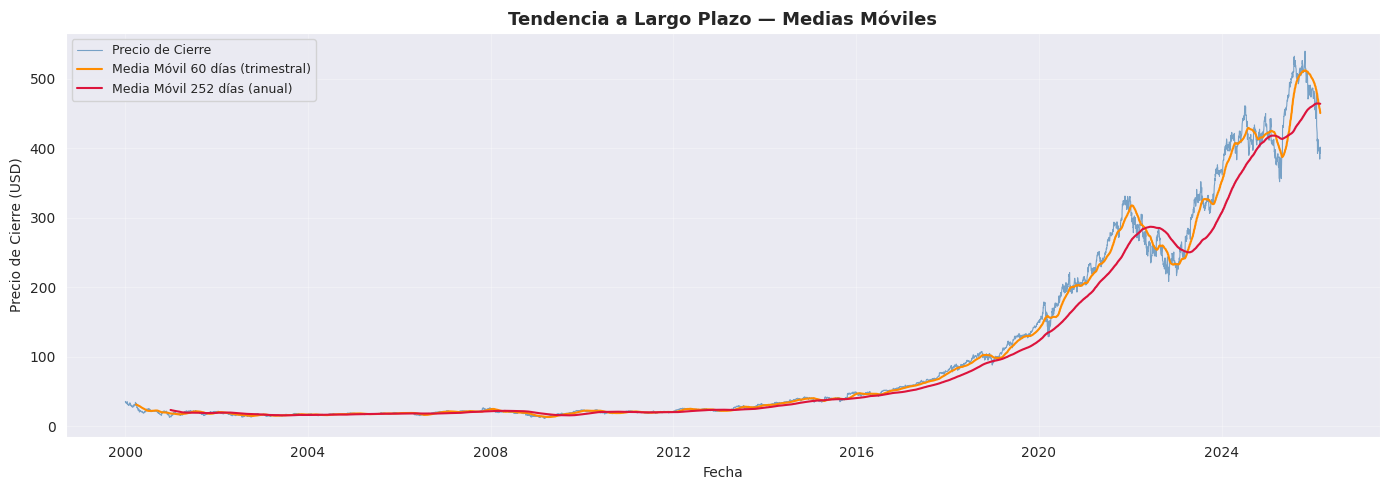

In [ ]:
# ── ─────────────────────────────────────────────
close_series['MM_60'] = close_series['Close'].rolling(window=60).mean()
close_series['MM_252'] = close_series['Close'].rolling(window=252).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Close'],
        color='steelblue', linewidth=0.8, label='Precio de Cierre', alpha=0.7)
ax.plot(close_series.index, close_series['MM_60'],
        color='darkorange', linewidth=1.5, label='Media Móvil 60 días (trimestral)')
ax.plot(close_series.index, close_series['MM_252'],
        color='crimson', linewidth=1.5, label='Media Móvil 252 días (anual)')

ax.set_title('Tendencia a Largo Plazo — Medias Móviles',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Precio de Cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
from statsmodels.tsa.holtwinters import ExponentialSmoothing



La gráfica muestra el precio de cierre junto con la media móvil de 60 días (corto–mediano plazo) y la media móvil de 252 días (largo plazo). Se observa una tendencia alcista muy marcada en el largo plazo, especialmente a partir de 2013–2014, lo que confirma el fuerte crecimiento estructural de la acción.

La media móvil de 60 días sigue más de cerca al precio y reacciona rápidamente a cambios, mientras que la de 252 días es más suave y refleja la tendencia estructural. Cuando la media de 60 días está por encima de la de 252 días, el mercado está en fase alcista sostenida; cuando cruza por debajo, suele indicar correcciones o fases bajistas (como en 2008, 2022 y algunos retrocesos recientes).
Mientras que la media móvil de 252 días es más suave y refleja la tendencia estructural de largo plazo, la de 60 días reacciona más rápido a los cambios recientes en el precio. Cuando la media de 60 días está por encima de la de 252 días, el mercado suele encontrarse en una fase alcista sostenida; cuando cruza por debajo, normalmente anticipa correcciones o fases bajistas (como se observa en 2008, 2022 y algunos retrocesos recientes).

En los últimos periodos se aprecia una mayor separación entre ambos medios, lo que refleja un fuerte impulso alcista, aunque acompañado de mayor volatilidad. En conjunto, la gráfica confirma una tendencia a largo plazo claramente positiva, con ciclos intermedios de corrección que no rompen la estructura alcista principal.

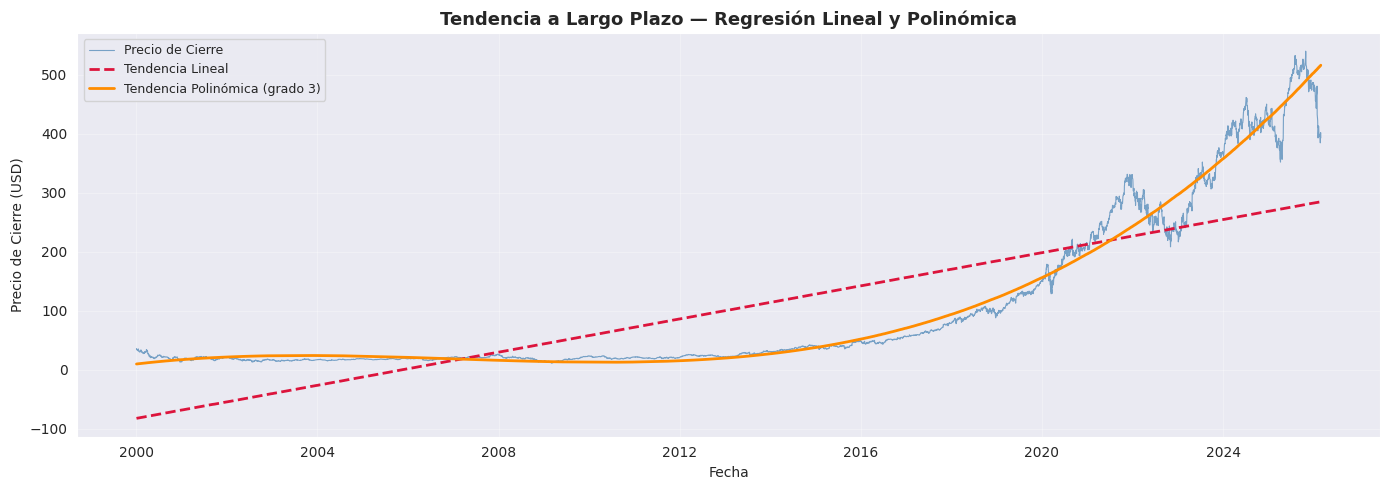

In [ ]:
# Preparar datos
close_clean = close_series['Close'].dropna()
X = np.arange(len(close_clean)).reshape(-1, 1)
y = close_clean.values

# Regresión lineal
lr = LinearRegression()
lr.fit(X, y)
y_lineal = lr.predict(X)

# Regresión polinómica grado 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)
y_polinómica = lr_poly.predict(X_poly)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_clean.index, close_clean.values,
        color='steelblue', linewidth=0.8, label='Precio de Cierre', alpha=0.7)
ax.plot(close_clean.index, y_lineal,
        color='crimson', linewidth=2.0, linestyle='--', label='Tendencia Lineal')
ax.plot(close_clean.index, y_polinómica,
        color='darkorange', linewidth=2.0, label='Tendencia Polinómica (grado 3)')

ax.set_title('Tendencia a Largo Plazo — Regresión Lineal y Polinómica',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Precio de Cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica compara el precio de cierre con una tendencia lineal y una tendencia polinómica de grado 3. La tendencia lineal (línea roja punteada) muestra una trayectoria creciente constante, pero no logra captar adecuadamente la dinámica real del precio, especialmente el fuerte crecimiento acelerado de los últimos años. mi

Por otro lado, la tendencia polinómica (línea naranja) se ajusta mucho mejor a la forma de la serie, ya que capta la curvatura y la aceleración del crecimiento, especialmente a partir de 2015. Esto refleja que el crecimiento del precio ha sido no lineal y con expansión exponencial en los últimos años.

En conclusión, la acción presenta una tendencia de largo plazo claramente alcista y creciente a un ritmo acelerado, por lo que un modelo lineal simple subestima la dinámica real, mientras que un modelo no lineal describe mejor la evolución estructural del precio.Esto es importante para visualizar tendencia limpia.

# Estabilidad de la serie

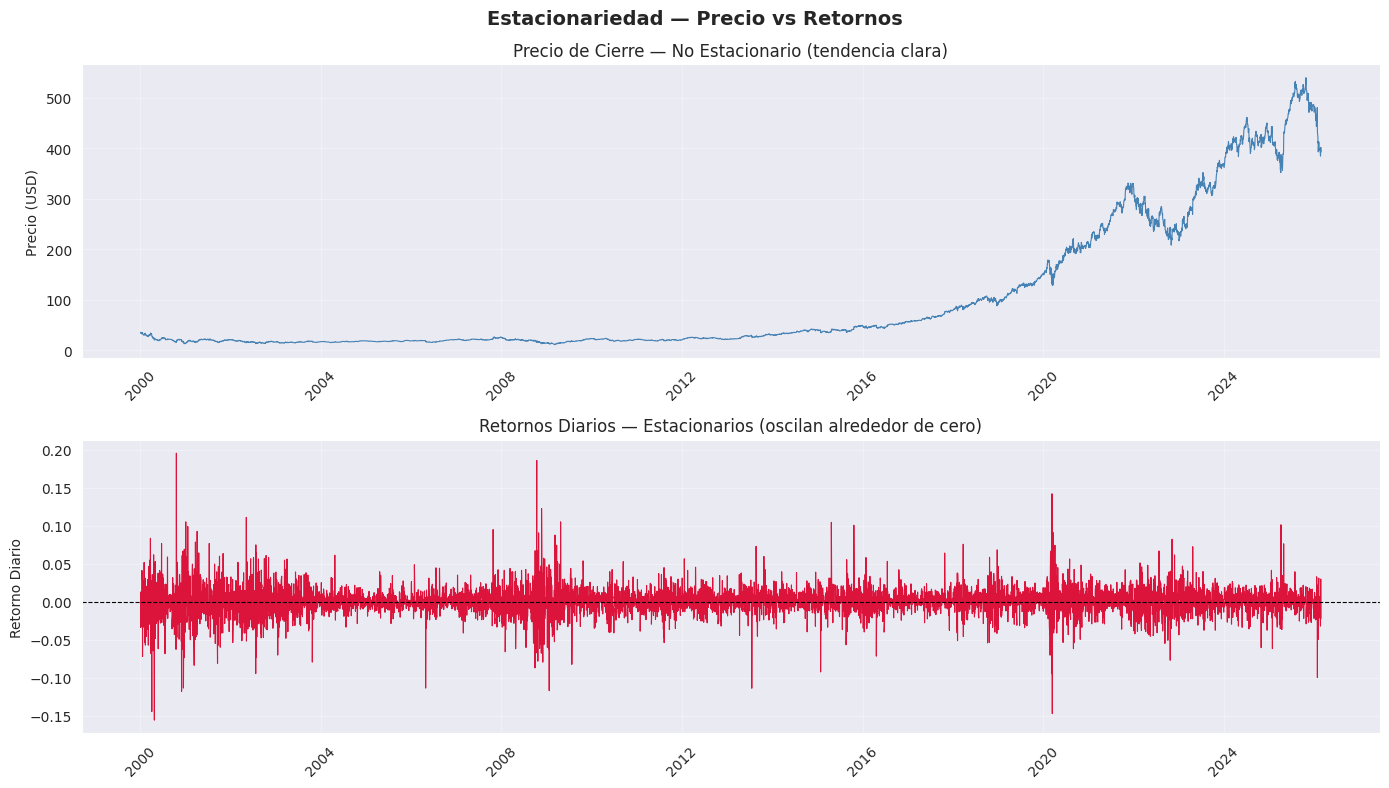


═
  RESUMEN ESTACIONARIEDAD
═
  Variable        | Estacionaria |
  ─
  Close (precio)  |      no      |
  Returns         |      si      |

═
  Prueba ADF — Precio de Cierre (Close)
═
  Estadístico ADF:     0.7140
  p-valor:             0.9901
  Lags utilizados:     32
  Observaciones:       6545

  Valores críticos:
    1%: -3.4313
    5%: -2.8620
    10%: -2.5670

 Conclusión:
   p-valor = 0.9901 > 0.05 → No se rechaza H₀
   La serie 'Precio de Cierre (Close)' NO ES ESTACIONARIA.

═
  Prueba ADF — Retornos Diarios (Returns)
═
  Estadístico ADF:     -28.0644
  p-valor:             0.0000
  Lags utilizados:     8
  Observaciones:       6568

  Valores críticos:
    1%: -3.4313
    5%: -2.8620
    10%: -2.5670

 Conclusión:
   p-valor = 0.0000 ≤ 0.05 → Se rechaza H₀
   La serie 'Retornos Diarios (Returns)' ES ESTACIONARIA.


In [ ]:
# Prueba ADF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Estacionariedad — Precio vs Retornos',
             fontsize=14, fontweight='bold')

axes[0].plot(close_series.index, close_series['Close'],
             color='steelblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre — No Estacionario (tendencia clara)', fontsize=12)
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(close_series.index, close_series['Returns'],
             color='crimson', linewidth=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Retornos Diarios — Estacionarios (oscilan alrededor de cero)', fontsize=12)
axes[1].set_ylabel('Retorno Diario')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


resultado = adfuller(serie.dropna())
    print(f"\n{'═'}")
    print(f"  Prueba ADF — {nombre}")
    print(f"{'═'}")
    print(f"  Estadístico ADF:     {resultado[0]:.4f}")
    print(f"  p-valor:             {resultado[1]:.4f}")
    print(f"  Lags utilizados:     {resultado[2]}")
    print(f"  Observaciones:       {resultado[3]}")
    print(f"\n  Valores críticos:")
    for key, val in resultado[4].items():
        print(f"    {key}: {val:.4f}")
    print(f"\n Conclusión:")
    if resultado[1] <= 0.05:
        print(f"   p-valor = {resultado[1]:.4f} ≤ 0.05 → Se rechaza H₀")
        print(f"   La serie '{nombre}' ES ESTACIONARIA.")
    else:
        print(f"   p-valor = {resultado[1]:.4f} > 0.05 → No se rechaza H₀")
        print(f"   La serie '{nombre}' NO ES ESTACIONARIA.")

prueba_adf(close_series['Close'], 'Precio de Cierre (Close)')
prueba_adf(close_series['Returns'], 'Retornos Diarios (Returns)')
print("\n═")
print("  RESUMEN ESTACIONARIEDAD")
print("═")
print("  Variable        | Estacionaria |")
print("  ─")
print("  Close (precio)  |      no      |")
print("  Returns         |      si      |")
def prueba_adf(serie, nombre):

Con el objetivo de analizar la estructura interna de la serie temporal del precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema aditivo (Dujmovic, 2025). Este procedimiento separa la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— bajo el supuesto de fluctuaciones estacionales de magnitud constante, representada como $Y_t = T_t + S_t + R_t$ (Jensen et al., 2018).

La serie evidencia no estacionariedad con tendencia creciente acelerada desde 2013-2015 y volatilidad creciente post-2019, confirmando heterocedasticidad en residuales típica de series financieras (Dujmovic, 2025; Jensen et al., 2018).
Esta prueba contrasta la hipótesis nula
$𝐻_0$ de presencia de raíz unitaria (serie no estacionaria) frente a la hipótesis alternativa de estacionariedad.

Para la serie de Precio de Cierre (Close), el estadístico ADF fue 0.7140 con un p-valor de 0.9901. Dado que el p-valor es ampliamente superior al nivel de significancia del 5%, no se rechaza la hipótesis nula. Además, el estadístico ADF es mayor (menos negativo) que todos los valores críticos reportados (1%, 5% y 10%), lo que confirma que la serie presenta raíz unitaria. En consecuencia, el precio de cierre no es estacionario en nivel. Este resultado es consistente con el análisis gráfico previo, donde se observó una tendencia creciente de largo plazo y cambios en la media a lo largo del tiempo.

En contraste, para la serie de Retornos Diarios (Returns), el estadístico ADF fue -28.0644 con un p-valor prácticamente igual a 0.0000. En este caso, el p-valor es menor que 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria. Adicionalmente, el estadístico es mucho más negativo que los valores críticos, lo que proporciona evidencia contundente de estacionariedad. Esto indica que la serie de retornos no presenta tendencia determinística ni raíz unitaria, y que sus fluctuaciones se mantienen alrededor de una media constante.

En conjunto, los resultados confirman un comportamiento típico de series financieras: los precios en niveles no son estacionarios, mientras que sus retornos sí lo son. Este hallazgo justifica el uso de los retornos para el modelamiento econométrico y el análisis de volatilidad, ya que la mayoría de los modelos de series de tiempo requieren estacionariedad para producir inferencias válidas.

# Conlusiones

Tras la evaluación rigurosa de la dinámica histórica de Microsoft (MSFT), se concluye que el activo presenta una estructura de serie de tiempo compleja cuya modelación directa en niveles de precios resultaría técnicamente inválida. La evidencia de no estacionariedad, ratificada por un p-valor de 0.9901 en la prueba ADF y una persistencia prolongada en la función de autocorrelación, confirma que la serie original está dominada por una tendencia estocástica creciente, lo que justifica la transformación obligatoria a retornos logarítmicos para estabilizar la varianza. El análisis de la distribución de estos retornos permite caracterizar el comportamiento del activo mediante una marcada leptocurtosis, indicando que el riesgo histórico está definido por una frecuencia de eventos extremos superior a la de una distribución normal, particularmente visible en las crisis financieras de las últimas dos décadas. Asimismo, la identificación de fenómenos de heterocedasticidad y clustering de volatilidad proporciona el fundamento empírico necesario para la implementación de modelos de varianza condicional, mientras que la descomposición estructural demuestra que la evolución de MSFT responde primordialmente a factores de crecimiento de largo plazo más que a patrones estacionales cíclicos. En síntesis, estos hallazgos resuelven la pregunta de investigación al establecer que la serie de MSFT requiere un tratamiento econométrico que gestione tanto la memoria en la varianza como la presencia de outliers, sentando las bases críticas para un despliegue de modelos predictivos robustos.

# Fuentes
**Hasan, M. (s.f.). Microsoft Stock Price Analysis using GARCH model in R. RPubs. https://rpubs.com/Mahmud_Hasan/778532 **

**Dujmovic, N. (2025, enero 4). Time series decomposition in machine learning. LinkedIn. https://www.linkedin.com/pulse/time-series-decomposition-machine-learning-neven-dujmovic-veuhf/**
​

**Jensen, C. G., Nielsen, M. Ø., & Chul, S. H. (2018). Time series decomposition and forecasting: Evidence from Danish pork prices (Working Paper No. 18-14). Department of Economics and Business Economics, Aarhus University. https://pure.au.dk/ws/files/126370851/rp18_14.pdf**

**DataCamp. (2025, 29 de abril). Descomposición de series temporales: Tendencias, estacionalidad y ruido. https://www.datacamp.com/es/tutorial/time-series-decomposition**
​

Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. Journal of Official Statistics, 6(1), 3-73.

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. Journal of Econometrics, 31(3), 307-327. https://doi.org/10.1016/0304-4076(86)90063-1

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. Econometrica, 50(4), 987-1007. https://doi.org/10.2307/1912773

Engle, R. F. (2001). The use of ARCH/GARCH models in applied econometrics. Journal of Economic Perspectives, 15(4), 157-168. https://doi
.org/10.1257/jep.15.4.157

CEPAL. (s.f.). Análisis de Series de Tiempo. https://www.cepal.org/sites/default/files/courses/files/01_1_conociendo_una_serie_de_tiempo.pdf

Morales, J. A. M. (2013). Análisis de Series Temporales. Universidad Complutense de Madrid. https://www.ucm.es/data/cont/docs/518-2013-11-11-JAM-IAST-Libro.pdf

